<a href="https://colab.research.google.com/github/aliciaseidou/Final-year-Project/blob/main/C22495584_FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries & Folders**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/FYP")
!pwd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/FYP


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import f_oneway, chi2_contingency, randint, uniform

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
!pip -q install xgboost
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report


# **Load In Datasets**


In [ ]:
#Load in 15-16 Datasets
Demo1516 = pd.read_sas('2015-2016/1516_Demo.xpt', format ='xport', encoding = 'utf-8')
Chlosteral1516 = pd.read_sas('2015-2016/1516_ChlostralHDI.xpt', format ='xport', encoding = 'utf-8')
BodyMeasurements1516 = pd.read_sas('2015-2016/1516_BodyMeasurements.xpt', format ='xport', encoding = 'utf-8')
BloodPressure1516 = pd.read_sas('2015-2016/1516_BloodPressure.xpt', format ='xport', encoding = 'utf-8')
ReproductiveHealth1516 = pd.read_sas('2015-2016/1516_ReproductiveHealth.xpt', format ='xport', encoding = 'utf-8')
Trigly1516 = pd.read_sas('2015-2016/1516_TRIGLY.xpt', format ='xport', encoding = 'utf-8')
Demo1516

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,83732.0,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,...,5.0,1.0,3.0,134671.370419,135629.507405,1.0,125.0,10.0,10.0,4.390000e+00
1,83733.0,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,...,3.0,3.0,NaN,24328.560239,25282.425927,1.0,125.0,4.0,4.0,1.320000e+00
2,83734.0,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,...,3.0,1.0,3.0,12400.008522,12575.838818,1.0,131.0,5.0,5.0,1.510000e+00
3,83735.0,9.0,2.0,2.0,56.0,NaN,3.0,3.0,2.0,NaN,...,5.0,6.0,NaN,102717.995647,102078.634508,1.0,131.0,10.0,10.0,5.000000e+00
4,83736.0,9.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,4.0,3.0,NaN,17627.674984,18234.736219,2.0,126.0,7.0,7.0,1.230000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9966,93698.0,9.0,2.0,1.0,2.0,NaN,1.0,1.0,1.0,30.0,...,1.0,2.0,NaN,9594.802391,9896.007775,1.0,121.0,6.0,6.0,5.100000e-01
9967,93699.0,9.0,2.0,2.0,6.0,NaN,4.0,4.0,2.0,75.0,...,5.0,1.0,NaN,9871.384668,9875.921047,1.0,129.0,15.0,15.0,4.580000e+00
9968,93700.0,9.0,2.0,1.0,35.0,NaN,3.0,3.0,2.0,NaN,...,1.0,1.0,1.0,42314.288108,43194.215112,1.0,126.0,1.0,1.0,5.397605e-79
9969,93701.0,9.0,2.0,1.0,8.0,NaN,3.0,3.0,2.0,106.0,...,5.0,1.0,5.0,42087.657815,48252.504294,2.0,124.0,15.0,15.0,4.220000e+00


In [ ]:
dfs = [
    Demo1516,
    Chlosteral1516,
    BodyMeasurements1516,
    BloodPressure1516,
    ReproductiveHealth1516,
    Trigly1516
]

merged_inner1516 = dfs[0]
for df in dfs[1:]:
    merged_inner1516 = merged_inner1516.merge(df, on="SEQN", how="outer")

merged_inner1516

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,RHQ586Q,RHQ586U,RHQ596,RHQ602Q,RHQ602U,WTSAF2YR,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI
0,83732.0,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,83733.0,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,54722.343330,147.0,1.660,173.0,4.474
2,83734.0,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,25471.093699,269.0,3.037,145.0,3.750
3,83735.0,9.0,2.0,2.0,56.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,83736.0,9.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,38179.510870,47.0,0.531,142.0,3.672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9966,93698.0,9.0,2.0,1.0,2.0,NaN,1.0,1.0,1.0,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9967,93699.0,9.0,2.0,2.0,6.0,NaN,4.0,4.0,2.0,75.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9968,93700.0,9.0,2.0,1.0,35.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9969,93701.0,9.0,2.0,1.0,8.0,NaN,3.0,3.0,2.0,106.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Load in 17-18 Datasets
Demo1718 = pd.read_sas('2017-2018/1718_Demo.xpt', format ='xport', encoding = 'utf-8')
Chlosteral1718 = pd.read_sas('2017-2018/1718_Chlostral_HDL.xpt', format ='xport', encoding = 'utf-8')
BodyMeasurements1718 = pd.read_sas('2017-2018/1718_BodyMeasurements.xpt', format ='xport', encoding = 'utf-8')
BloodPressure1718 = pd.read_sas('2017-2018/1718_BloodPressure.xpt', format ='xport', encoding = 'utf-8')
ReproductiveHealth1718 = pd.read_sas('2017-2018/1718_ReproductiveHealth.xpt', format ='xport', encoding = 'utf-8')
Trigly1718 = pd.read_sas('2017-2018/1718_TRIGLY.xpt', format ='xport', encoding = 'utf-8')
Demo1718

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,3.0,1.0,2.0,8548.632619,8723.439814,2.0,134.0,NaN,NaN,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,2.0,1.0,3.0,6769.344567,7064.609730,1.0,138.0,10.0,10.0,1.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9249,102952.0,10.0,2.0,2.0,70.0,NaN,5.0,6.0,2.0,NaN,...,2.0,1.0,1.0,16896.276203,18338.711104,2.0,138.0,4.0,4.0,0.95
9250,102953.0,10.0,2.0,1.0,42.0,NaN,1.0,1.0,2.0,NaN,...,2.0,2.0,NaN,61630.380013,63661.951573,2.0,137.0,12.0,12.0,NaN
9251,102954.0,10.0,2.0,2.0,41.0,NaN,4.0,4.0,1.0,NaN,...,2.0,2.0,NaN,17160.895269,17694.783346,1.0,144.0,10.0,10.0,1.18
9252,102955.0,10.0,2.0,2.0,14.0,NaN,4.0,4.0,2.0,175.0,...,2.0,1.0,2.0,14238.445922,14871.839636,1.0,136.0,9.0,9.0,2.24


In [ ]:
dfs2 = [
    Demo1718,
    Chlosteral1718,
    BodyMeasurements1718,
    BloodPressure1718,
    ReproductiveHealth1718,
    Trigly1718
]

merged_inner1718 = dfs2[0]
for df in dfs2[1:]:
    merged_inner1718 = merged_inner1718.merge(df, on="SEQN", how="outer")

merged_inner1718

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,RHQ602U,WTSAF2YR,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI,LBDLDLM,LBDLDMSI,LBDLDLN,LBDLDNSI
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9249,102952.0,10.0,2.0,2.0,70.0,NaN,5.0,6.0,2.0,NaN,...,NaN,32733.048593,78.0,0.881,43.0,1.112,43.0,1.112,43.0,1.112
9250,102953.0,10.0,2.0,1.0,42.0,NaN,1.0,1.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9251,102954.0,10.0,2.0,2.0,41.0,NaN,4.0,4.0,1.0,NaN,...,NaN,50637.453793,49.0,0.553,108.0,2.793,104.0,2.689,108.0,2.793
9252,102955.0,10.0,2.0,2.0,14.0,NaN,4.0,4.0,2.0,175.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Load in 13-14 Datasets
Demo1314 = pd.read_sas('2013-2014/DEMO_H.xpt', format ='xport', encoding = 'utf-8')
Chlosteral1314 = pd.read_sas('2013-2014/HDL_H.xpt', format ='xport', encoding = 'utf-8')
BodyMeasurements1314 = pd.read_sas('2013-2014/BMX_H.xpt', format ='xport', encoding = 'utf-8')
BloodPressure1314 = pd.read_sas('2013-2014/BPX_H.xpt', format ='xport', encoding = 'utf-8')
ReproductiveHealth1314 = pd.read_sas('2013-2014/RHQ_H.xpt', format ='xport', encoding = 'utf-8')
Trigly1314= pd.read_sas('2013-2014/TRIGLY_H.xpt', format ='xport', encoding = 'utf-8')

In [ ]:
dfs4 = [
    Demo1314,
    BodyMeasurements1314,
    Chlosteral1314,
    BloodPressure1314,
    ReproductiveHealth1314,
    Trigly1314
]

merged_inner1314 = dfs4[0]
for df in dfs4[1:]:
    merged_inner1314 = merged_inner1314.merge(df, on="SEQN", how="outer")

merged_inner1314

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,RHQ586Q,RHQ586U,RHQ596,RHQ602Q,RHQ602U,WTSAF2YR,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI
0,73557.0,8.0,2.0,1.0,69.0,NaN,4.0,4.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,73558.0,8.0,2.0,1.0,54.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,73559.0,8.0,2.0,1.0,72.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,142196.890197,51.0,0.576,56.0,1.448
3,73560.0,8.0,2.0,1.0,9.0,NaN,3.0,3.0,1.0,119.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,73561.0,8.0,2.0,2.0,73.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,142266.006548,75.0,0.847,101.0,2.612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10170,83727.0,8.0,2.0,1.0,26.0,NaN,2.0,2.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,67775.162806,81.0,0.914,119.0,3.077
10171,83728.0,8.0,2.0,2.0,2.0,24.0,1.0,1.0,2.0,24.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10172,83729.0,8.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10173,83730.0,8.0,2.0,1.0,7.0,NaN,2.0,2.0,1.0,84.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Load in 21-23 Datasets
Demo2123 = pd.read_sas('2021-2023/DEMO_L.xpt', format ='xport', encoding = 'utf-8')
Chlosteral2123 = pd.read_sas('2021-2023/2123_CholestralHDL.xpt', format ='xport', encoding = 'utf-8')
BodyMeasurements2123 = pd.read_sas('2021-2023/BMX_L.xpt', format ='xport', encoding = 'utf-8')
BloodPressure2123 = pd.read_sas('2021-2023/2123_BloodP.xpt', format ='xport', encoding = 'utf-8')
ReproductiveHealth2123 = pd.read_sas('2021-2023/RHQ_L.xpt', format ='xport', encoding = 'utf-8')
Trigly2123= pd.read_sas('2021-2023/2123_TRIGLY.xpt', format ='xport', encoding = 'utf-8')

In [ ]:
dfs3 = [
     Demo2123,
     BodyMeasurements2123,
     Chlosteral2123,
     BloodPressure2123,
     ReproductiveHealth2123,
     Trigly2123
 ]

merged_inner2123 = dfs3[0]
for df in dfs3[1:]:
       merged_inner2123 = merged_inner2123.merge(df, on="SEQN", how="outer")

merged_inner2123

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,RHQ332,WTSAF2YR,LBXTLG,LBDTRSI,LBDLDL,LBDLDLSI,LBDLDLM,LBDLDMSI,LBDLDLN,LBDLDNSI
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,1.200253e+05,153.0,1.727,188.0,4.862,190.0,4.913,191.0,4.939
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,5.397605e-79,86.0,0.971,137.0,3.543,135.0,3.491,139.0,3.595
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,1.450908e+05,375.0,4.234,63.0,1.629,90.0,2.327,78.0,2.017
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11928,142306.0,12.0,2.0,1.0,9.0,NaN,2.0,2.0,1.0,111.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11929,142307.0,12.0,2.0,2.0,49.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11930,142308.0,12.0,2.0,1.0,50.0,NaN,2.0,2.0,1.0,NaN,...,NaN,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11931,142309.0,12.0,2.0,1.0,40.0,NaN,2.0,2.0,1.0,NaN,...,NaN,7.512220e+04,104.0,1.174,180.0,4.655,179.0,4.629,183.0,4.732


In [ ]:
#Load in Pandemic Datasets
DemoPandemic = pd.read_sas('2019-2020/P_DEMO.xpt', format ='xport', encoding = 'utf-8')
ChlosteralPandemic = pd.read_sas('2019-2020/Pandemic_HDL.xpt', format ='xport', encoding = 'utf-8')
BodyMeasurementsPandemic = pd.read_sas('2019-2020/P_BMX.xpt', format ='xport', encoding = 'utf-8')
BloodPressurePandemic = pd.read_sas('2019-2020/P_BPXO.xpt', format ='xport', encoding = 'utf-8')
ReproductiveHealthPandemic = pd.read_sas('2019-2020/Pandemic_Repro.xpt', format ='xport', encoding = 'utf-8')

In [ ]:
dfsPandemic = [
     DemoPandemic,
     BodyMeasurementsPandemic,
     ChlosteralPandemic,
     BloodPressurePandemic,
     ReproductiveHealthPandemic,
 ]

merged_innerPandemic = dfsPandemic[0]
for df in dfsPandemic[1:]:
       merged_innerPandemic = merged_innerPandemic.merge(df, on="SEQN", how="outer")

merged_innerPandemic

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,RHD280,RHQ305,RHQ332,RHQ540,RHQ542A,RHQ542B,RHQ542C,RHQ542D,RHQ554,RHQ570
0,109263.0,66.0,2.0,1.0,2.0,NaN,5.0,6.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,109264.0,66.0,2.0,2.0,13.0,NaN,1.0,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109265.0,66.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109266.0,66.0,2.0,2.0,29.0,NaN,5.0,6.0,2.0,2.0,...,2.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,109267.0,66.0,1.0,2.0,21.0,NaN,2.0,2.0,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15555,124818.0,66.0,2.0,1.0,40.0,NaN,4.0,4.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15556,124819.0,66.0,2.0,1.0,2.0,NaN,4.0,4.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15557,124820.0,66.0,2.0,2.0,7.0,NaN,3.0,3.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15558,124821.0,66.0,2.0,1.0,63.0,NaN,4.0,4.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
combined = pd.concat([merged_inner1516, merged_inner1718, merged_inner1314, merged_inner2123, merged_innerPandemic], ignore_index=True)

combined

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,RHD167,LBXTLG,DMDYRUSZ,WTINTPRP,WTMECPRP
0,83732.0,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,83733.0,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,83734.0,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,83735.0,9.0,2.0,2.0,56.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,83736.0,9.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56888,124818.0,66.0,2.0,1.0,40.0,NaN,4.0,4.0,1.0,NaN,...,95.0,70.0,120.0,119.0,118.0,NaN,NaN,NaN,21586.596728,21666.889837
56889,124819.0,66.0,2.0,1.0,2.0,NaN,4.0,4.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1664.919253,1838.169709
56890,124820.0,66.0,2.0,2.0,7.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14819.783161,16497.806674
56891,124821.0,66.0,2.0,1.0,63.0,NaN,4.0,4.0,1.0,NaN,...,129.0,67.0,60.0,61.0,61.0,NaN,NaN,NaN,4666.817952,4853.430230


In [ ]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56893 entries, 0 to 56892
Columns: 176 entries, SEQN to WTMECPRP
dtypes: float64(175), object(1)
memory usage: 76.4+ MB


In [ ]:
cols_names = {'SEQN': 'SEQN',
              #Demo
             'RIAGENDR': 'gender',
             'RIDAGEYR' : 'age',
             'RIDRETH1': 'race',
              #Body Meausures
              'BMXWT':'weight(kg)',
              'BMXHT': 'height(cm)',
              'BMXBMI': 'BMI',
              'BMXARMC': 'Arm Circumference(cm)',
              'BMXWAIST': 'Waist Circumference (cm)',
              #Reproductive Health
              'RHQ031':'Had regular periods in past 12 months',
              'RHD043':'Reason not having regular periods',
              'RHQ074':'Tried for a year to become pregnant?',
              'RHQ131': 'Ever been pregnant?',
              "RHQ010" : "age at menarche",
              "RHQ160" : "number pregnancies",
              "RHQ171" : "live births",
              #Blood Pressure
              'BPXSY1':'Systolic BP_y',
              'BPXOSY1': 'Systolic BP_x',
              'BPXDI1':'Diastolic BP_x',
              'BPXODI1': 'Diastolic BP_y',
              #Chloestral
              'LBDHDD':'HDL',

}

In [ ]:
col_keep = cols_to_keep = [
    'SEQN',        # Respondent sequence number
    'RIAGENDR',    # Gender
    'RIDAGEYR',    # Age
    'RIDRETH1',    # Race/Hispanic origin
    'BMXWT',       # Weight (kg)
    'BMXHT',       # Height (cm)
    'BMXBMI',      # Body Mass Index
    'BMXARMC',     # Arm circumference (cm)
    'BMXWAIST',    # Waist circumference (cm)
    'RHQ031',      # Regular periods in past 12 months
    'RHD043',      # Reason not having regular periods
    'RHQ074',      # Tried for a year to become pregnant?
    'RHQ131',      # Ever been pregnant?
    "RHQ010",      # Age at menarche
    "RHQ160",      # Number pregnancies
    "RHQ171",      # Live births
    'BPXSY1',      # Systolic BP
    'BPXOSY1',     # Systolic BP
    'BPXDI1',      # Diastolic BP'
    'BPXODI1',     # Diastolic BP_y'
    'LBDHDD',      # HDL
]


In [ ]:
combined = combined[col_keep]
combined

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,BMXWT,BMXHT,BMXBMI,BMXARMC,BMXWAIST,RHQ031,...,RHQ074,RHQ131,RHQ010,RHQ160,RHQ171,BPXSY1,BPXOSY1,BPXDI1,BPXODI1,LBDHDD
0,83732.0,1.0,62.0,3.0,94.8,184.5,27.8,35.9,101.1,NaN,...,NaN,NaN,NaN,NaN,NaN,128.0,NaN,70.0,NaN,46.0
1,83733.0,1.0,53.0,3.0,90.4,171.4,30.8,33.2,107.9,NaN,...,NaN,NaN,NaN,NaN,NaN,146.0,NaN,88.0,NaN,63.0
2,83734.0,1.0,78.0,3.0,83.4,170.1,28.8,31.0,116.5,NaN,...,NaN,NaN,NaN,NaN,NaN,138.0,NaN,46.0,NaN,30.0
3,83735.0,2.0,56.0,3.0,109.8,160.9,42.4,38.3,110.1,2.0,...,2.0,2.0,12.0,NaN,NaN,132.0,NaN,72.0,NaN,61.0
4,83736.0,2.0,42.0,4.0,55.2,164.9,20.3,27.2,80.4,1.0,...,2.0,1.0,13.0,7.0,5.0,100.0,NaN,70.0,NaN,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56888,124818.0,1.0,40.0,4.0,108.8,168.7,38.2,33.6,114.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,106.0,NaN,67.0,50.0
56889,124819.0,1.0,2.0,4.0,15.4,93.7,17.5,15.8,48.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56890,124820.0,2.0,7.0,3.0,22.9,123.3,15.1,18.5,57.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0
56891,124821.0,1.0,63.0,4.0,79.5,176.4,25.5,31.4,97.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,121.0,NaN,66.0,44.0


In [ ]:
combined = combined.rename(columns=cols_names)
combined

,SEQN,gender,age,race,weight(kg),height(cm),BMI,Arm Circumference(cm),Waist Circumference (cm),Had regular periods in past 12 months,...,Tried for a year to become pregnant?,Ever been pregnant?,age at menarche,number pregnancies,live births,Systolic BP_y,Systolic BP_x,Diastolic BP_x,Diastolic BP_y,HDL
0,83732.0,1.0,62.0,3.0,94.8,184.5,27.8,35.9,101.1,NaN,...,NaN,NaN,NaN,NaN,NaN,128.0,NaN,70.0,NaN,46.0
1,83733.0,1.0,53.0,3.0,90.4,171.4,30.8,33.2,107.9,NaN,...,NaN,NaN,NaN,NaN,NaN,146.0,NaN,88.0,NaN,63.0
2,83734.0,1.0,78.0,3.0,83.4,170.1,28.8,31.0,116.5,NaN,...,NaN,NaN,NaN,NaN,NaN,138.0,NaN,46.0,NaN,30.0
3,83735.0,2.0,56.0,3.0,109.8,160.9,42.4,38.3,110.1,2.0,...,2.0,2.0,12.0,NaN,NaN,132.0,NaN,72.0,NaN,61.0
4,83736.0,2.0,42.0,4.0,55.2,164.9,20.3,27.2,80.4,1.0,...,2.0,1.0,13.0,7.0,5.0,100.0,NaN,70.0,NaN,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56888,124818.0,1.0,40.0,4.0,108.8,168.7,38.2,33.6,114.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,106.0,NaN,67.0,50.0
56889,124819.0,1.0,2.0,4.0,15.4,93.7,17.5,15.8,48.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56890,124820.0,2.0,7.0,3.0,22.9,123.3,15.1,18.5,57.5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0
56891,124821.0,1.0,63.0,4.0,79.5,176.4,25.5,31.4,97.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,121.0,NaN,66.0,44.0


In [ ]:
combined['Systolic BP'] = combined['Systolic BP_x'].combine_first(combined['Systolic BP_y'])
combined.drop(columns=['Systolic BP_x', 'Systolic BP_y'], inplace=True)

In [ ]:
combined['Diastolic BP'] = combined['Diastolic BP_x'].combine_first(combined['Diastolic BP_y'])
combined.drop(columns=['Diastolic BP_x', 'Diastolic BP_y'], inplace=True)

# **Preprocesses**

In [ ]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56893 entries, 0 to 56892
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SEQN                                   56893 non-null  float64
 1   gender                                 56893 non-null  float64
 2   age                                    56893 non-null  float64
 3   race                                   56893 non-null  float64
 4   weight(kg)                             50577 non-null  float64
 5   height(cm)                             47508 non-null  float64
 6   BMI                                    47424 non-null  float64
 7   Arm Circumference(cm)                  48496 non-null  float64
 8   Waist Circumference (cm)               45339 non-null  float64
 9   Had regular periods in past 12 months  17552 non-null  float64
 10  Reason not having regular periods      8317 non-null   float64
 11  Tr

In [ ]:
#Creating BMI category variable
combined["BMI_Category"] = pd.cut(combined["BMI"], bins=[0, 18.5, 25, 30, 100], labels=["Underweight", "Normal", "Overweight", "Obese"])

In [ ]:
#All women dataset
combined = combined[combined['gender'] != 1.0]
combined

,SEQN,gender,age,race,weight(kg),height(cm),BMI,Arm Circumference(cm),Waist Circumference (cm),Had regular periods in past 12 months,Reason not having regular periods,Tried for a year to become pregnant?,Ever been pregnant?,age at menarche,number pregnancies,live births,HDL,Systolic BP,Diastolic BP,BMI_Category
3,83735.0,2.0,56.0,3.0,109.8,160.9,42.4,38.3,110.1,2.0,7.0,2.0,2.0,12.0,NaN,NaN,61.0,132.0,72.0,Obese
4,83736.0,2.0,42.0,4.0,55.2,164.9,20.3,27.2,80.4,1.0,NaN,2.0,1.0,13.0,7.0,5.0,53.0,100.0,70.0,Normal
5,83737.0,2.0,72.0,1.0,64.4,150.0,28.6,31.4,92.9,2.0,7.0,NaN,1.0,12.0,3.0,2.0,78.0,116.0,58.0,Overweight
6,83738.0,2.0,11.0,1.0,37.2,143.5,18.1,21.7,67.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,102.0,36.0,Underweight
10,83742.0,2.0,32.0,1.0,64.5,151.3,28.2,31.5,93.3,1.0,NaN,2.0,1.0,13.0,3.0,3.0,28.0,120.0,70.0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56880,124810.0,2.0,56.0,4.0,116.9,167.4,41.7,40.7,120.0,2.0,3.0,2.0,2.0,13.0,NaN,NaN,37.0,130.0,82.0,Obese
56882,124812.0,2.0,62.0,2.0,73.0,159.6,28.7,31.4,99.3,2.0,7.0,NaN,1.0,13.0,5.0,3.0,66.0,165.0,91.0,Overweight
56883,124813.0,2.0,43.0,4.0,78.6,168.5,27.7,36.0,98.5,1.0,NaN,1.0,1.0,13.0,2.0,NaN,52.0,126.0,86.0,Overweight
56887,124817.0,2.0,67.0,1.0,82.8,147.8,37.9,39.5,110.0,2.0,3.0,NaN,1.0,14.0,5.0,5.0,60.0,111.0,69.0,Obese


In [ ]:
#remove under 21
combined = combined[combined['age'] >= 21]
combined['age'].describe()

,age
count,17692.000000
mean,51.388085
std,17.431895
min,21.000000
25%,36.000000
50%,52.000000
75%,66.000000
max,80.000000


In [ ]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17692 entries, 3 to 56887
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   17692 non-null  float64 
 1   gender                                 17692 non-null  float64 
 2   age                                    17692 non-null  float64 
 3   race                                   17692 non-null  float64 
 4   weight(kg)                             15814 non-null  float64 
 5   height(cm)                             15824 non-null  float64 
 6   BMI                                    15792 non-null  float64 
 7   Arm Circumference(cm)                  15222 non-null  float64 
 8   Waist Circumference (cm)               14967 non-null  float64 
 9   Had regular periods in past 12 months  14387 non-null  float64 
 10  Reason not having regular periods      8305 non-null   float64 

In [ ]:
#Drops NaN Values of these variables
combined = combined.dropna(subset=['weight(kg)',
                                   'height(cm)',
                                    'BMI',
                                   'Had regular periods in past 12 months',
                                    'Waist Circumference (cm)',
                                    'Arm Circumference(cm)',
                                    'Diastolic BP',
                                    'Systolic BP',
                                    'HDL',
                                   ])

In [ ]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12171 entries, 3 to 56887
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   12171 non-null  float64 
 1   gender                                 12171 non-null  float64 
 2   age                                    12171 non-null  float64 
 3   race                                   12171 non-null  float64 
 4   weight(kg)                             12171 non-null  float64 
 5   height(cm)                             12171 non-null  float64 
 6   BMI                                    12171 non-null  float64 
 7   Arm Circumference(cm)                  12171 non-null  float64 
 8   Waist Circumference (cm)               12171 non-null  float64 
 9   Had regular periods in past 12 months  12171 non-null  float64 
 10  Reason not having regular periods      6920 non-null   float64 

Dataset is still not 100% Clean but variables:

•	Age

•	BMI

•	Waist circumference

•	Arm circumference

•	Systolic blood pressure

•	Diastolic blood pressure

•	HDL cholesterol

are clean so we begin clustering

# **Clustering**

In [163]:
#Decided on these variables due to literature
#Clean no NaN Dataset
cluster_cols = ["age","BMI",
                "Waist Circumference (cm)",
                "Arm Circumference(cm)",
                "Systolic BP",
                "Diastolic BP",
                "HDL"]
#Create Cluster dataset
#Clean, no NaN Dataset
cluster_df = combined[cluster_cols]
cluster_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12171 entries, 3 to 56887
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       12171 non-null  float64
 1   BMI                       12171 non-null  float64
 2   Waist Circumference (cm)  12171 non-null  float64
 3   Arm Circumference(cm)     12171 non-null  float64
 4   Systolic BP               12171 non-null  float64
 5   Diastolic BP              12171 non-null  float64
 6   HDL                       12171 non-null  float64
dtypes: float64(7)
memory usage: 760.7 KB


In [164]:
# file_path = '/content/drive/MyDrive//Colab Notebooks/FYP/Cluster_Dataset.csv'

# cluster_df.to_csv(file_path, index=False)

## Scaling

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df)

In [ ]:
X

array([[ 0.3009997 ,  1.59281842,  0.6435682 , ...,  0.48384894,
         0.01436937,  0.16209655],
       [-0.52152525, -1.27336349, -1.08793305, ..., -1.14714997,
        -0.14563944, -0.3285621 ],
       [ 1.24102822, -0.19692413, -0.35918673, ..., -0.33165051,
        -1.10569229,  1.20474616],
       ...,
       [ 0.6535104 , -0.18395498,  0.01393138, ...,  2.16581656,
         1.53445305,  0.4687582 ],
       [-0.46277347, -0.31364647, -0.03270838, ...,  0.17803664,
         1.13443103, -0.38989443],
       [ 0.94726931,  1.00920672,  0.63773823, ..., -0.58649409,
        -0.22564384,  0.10076422]])

## Choose K

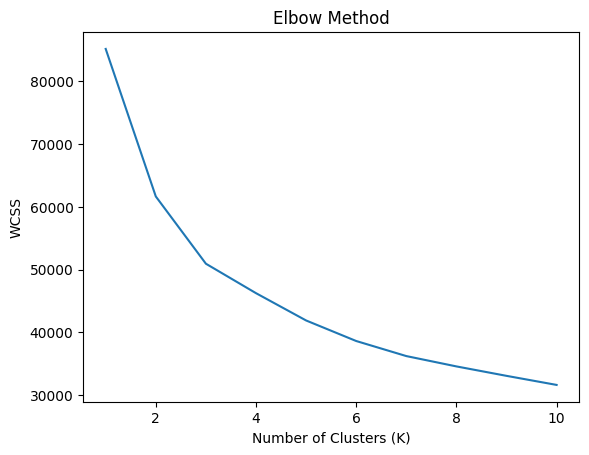

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
#assume K means
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    print(f"K={k}, Silhouette={silhouette_score(X, labels):.4f}")

K=2, Silhouette=0.2488
K=3, Silhouette=0.2255
K=4, Silhouette=0.1887
K=5, Silhouette=0.1820
K=6, Silhouette=0.1846


Decide K=3

## Run Clustering Models

Run KMeans( Baseline)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["KMeans_Cluster"] = kmeans.fit_predict(X)

/tmp/ipykernel_8159/2256520806.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df["KMeans_Cluster"] = kmeans.fit_predict(X)


Run GMM

In [ ]:
gmm = GaussianMixture(n_components=3, random_state=42)
cluster_df["GMM_Cluster"] = gmm.fit_predict(X)

/tmp/ipykernel_8159/2147654163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df["GMM_Cluster"] = gmm.fit_predict(X)


Run Hierarchical

In [ ]:
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
cluster_df["Hier_Cluster"] = hier.fit_predict(X)

/tmp/ipykernel_8159/1161426829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df["Hier_Cluster"] = hier.fit_predict(X)


Validation Block

In [ ]:
print("KMeans Silhouette:", silhouette_score(X, cluster_df["KMeans_Cluster"]))
print("GMM Silhouette:", silhouette_score(X, cluster_df["GMM_Cluster"]))
print("Hier Silhouette:", silhouette_score(X, cluster_df["Hier_Cluster"]))

KMeans Silhouette: 0.22540808101974566
GMM Silhouette: 0.18670840518952636
Hier Silhouette: 0.14246518149255838


Kmeans as Silhouette Score is the highest,

Choose KMeans as model

## Run K Means

In [ ]:
#K means ran with 10 iterations
#Create Cluster Column
combined["Cluster"] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
combined['Cluster']

,Cluster
3,2
4,1
5,0
10,1
20,1
...,...
56879,1
56880,2
56882,0
56883,0


In [ ]:
#Evaluate Centroids of the clusters
combined.groupby("Cluster")[[
    "age","BMI",
    "Waist Circumference (cm)",
    "Arm Circumference(cm)",
    "Systolic BP",
    "Diastolic BP",
    "HDL"
]].mean()

,age,BMI,Waist Circumference (cm),Arm Circumference(cm),Systolic BP,Diastolic BP,HDL
Cluster,,,,,,,
0,65.468558,27.515296,95.579125,30.624823,137.522695,74.860757,62.537825
1,38.513507,25.018072,86.137285,29.376246,108.210293,66.487191,61.285980
2,48.508911,39.142802,118.316068,39.024623,121.923773,74.573348,50.059501


**Cluster** **0**

This cluster is clearly the oldest group.

It also has the highest systolic BP.

BMI is in the overweight range.

**Cluster 1**

Youngest cluster

Lowest BMI

Lowest BP

Relatively high HDL

**Cluster 2**

Highest BMI

Highest waist circumference

Lowest HDL

In [ ]:
#Name Clusters based on centroids
combined['Cluster'] = combined['Cluster'].replace({
    0: 'older, overweight',
    1: 'young, normal weight',
    2: 'mid-age, obese'
})

In [ ]:
#Cluster Balance
combined["Cluster"].value_counts()

,count
Cluster,
"young, normal weight",4294
"older, overweight",4230
"mid-age, obese",3647


Clusters are well balanced

## Evaluate Cluster Performance

In [ ]:
cluster_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12171 entries, 3 to 56887
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       12171 non-null  float64
 1   BMI                       12171 non-null  float64
 2   Waist Circumference (cm)  12171 non-null  float64
 3   Arm Circumference(cm)     12171 non-null  float64
 4   Systolic BP               12171 non-null  float64
 5   Diastolic BP              12171 non-null  float64
 6   HDL                       12171 non-null  float64
 7   KMeans_Cluster            12171 non-null  int32  
 8   GMM_Cluster               12171 non-null  int64  
 9   Hier_Cluster              12171 non-null  int64  
dtypes: float64(7), int32(1), int64(2)
memory usage: 998.4 KB


In [ ]:
df_train, df_test = train_test_split\
                    (cluster_df[cluster_cols], train_size=0.75, \
                     random_state=42)

print(df_train.shape)
print(df_test.shape)

(9128, 7)
(3043, 7)


In [ ]:
model = KMeans(n_clusters=3, random_state=42)

df_train['Cluster'] = model.fit_predict(df_train[cluster_cols])
silhouette_avg = silhouette_score\
                 (df_train[cluster_cols], df_train['Cluster'])
print(silhouette_avg)

0.22910439924774223


In [ ]:
df_test['Cluster'] = model.predict(df_test[cluster_cols])
silhouette_avg = silhouette_score\
                 (df_test[cluster_cols],df_test['Cluster'])
print(silhouette_avg)

0.22844336890494826


## PCA

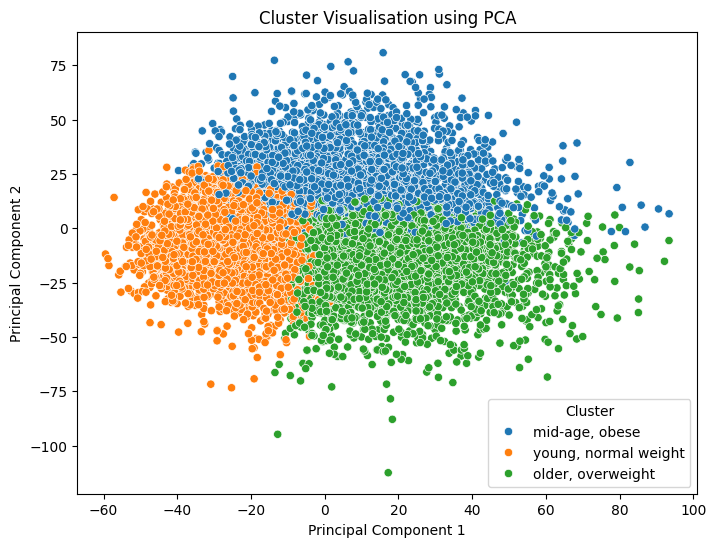

In [ ]:
#2 dimensional PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(combined[cluster_cols])

#Create PCA DF
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': combined['Cluster']
})


plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster')
plt.title('Cluster Visualisation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Chi Squared

In [ ]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12171 entries, 3 to 56887
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   12171 non-null  float64 
 1   gender                                 12171 non-null  float64 
 2   age                                    12171 non-null  float64 
 3   race                                   12171 non-null  float64 
 4   weight(kg)                             12171 non-null  float64 
 5   height(cm)                             12171 non-null  float64 
 6   BMI                                    12171 non-null  float64 
 7   Arm Circumference(cm)                  12171 non-null  float64 
 8   Waist Circumference (cm)               12171 non-null  float64 
 9   Had regular periods in past 12 months  12171 non-null  float64 
 10  Reason not having regular periods      6920 non-null   float64 

### Clusters with Race

In [ ]:
race_map = {
1: "Mexican American",
2: "Other Hispanic",
3: "Non-Hispanic White",
4: "Non-Hispanic Black",
5: "Other"
}

combined['race_label'] = combined['race'].map(race_map)
combined['race_label'].value_counts(dropna = False)

,count
race_label,
Non-Hispanic White,5205
Non-Hispanic Black,2423
Other,1708
Mexican American,1507
Other Hispanic,1328


In [ ]:
race_cluster = pd.crosstab(combined['Cluster'], combined['race_label'])
print(race_cluster)

race_label            Mexican American  Non-Hispanic Black  \
Cluster                                                      
mid-age, obese                     518                1022   
older, overweight                  396                 771   
young, normal weight               593                 630   

race_label            Non-Hispanic White  Other  Other Hispanic  
Cluster                                                          
mid-age, obese                      1487    254             366  
older, overweight                   2008    588             467  
young, normal weight                1710    866             495  


In [ ]:
chi2, p, dof, expected = chi2_contingency(race_cluster)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 516.9390393349829
p-value: 1.630200653948397e-106


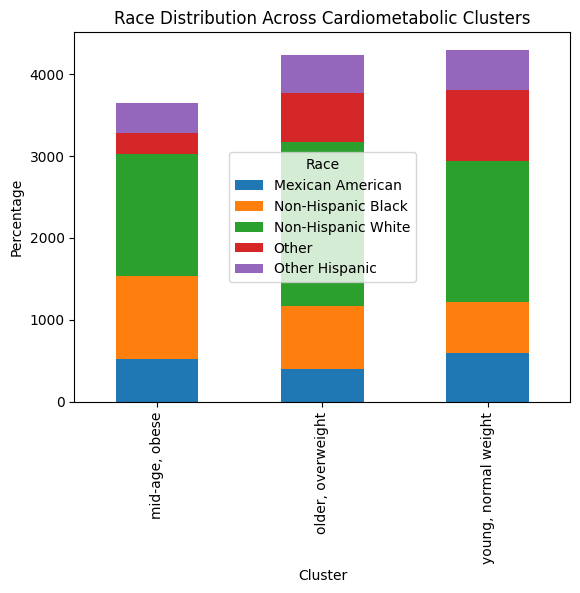

In [ ]:
race_cluster.plot(kind='bar', stacked=True)

plt.title("Race Distribution Across Cardiometabolic Clusters")
plt.ylabel("Percentage")
plt.xlabel("Cluster")
plt.legend(title="Race")
plt.show()

### Clusters with BMI Categories


In [ ]:
combined['BMI_Category'].value_counts(dropna = False)

,count
BMI_Category,
Obese,5296
Overweight,3443
Normal,3232
Underweight,200


In [ ]:
bmi_cluster = pd.crosstab(combined['Cluster'], combined['BMI_Category'])
print(bmi_cluster)

BMI_Category          Underweight  Normal  Overweight  Obese
Cluster                                                     
mid-age, obese                  0       0          26   3621
older, overweight              46    1151        1869   1164
young, normal weight          154    2081        1548    511


In [ ]:
chi2, p, dof, expected = chi2_contingency(bmi_cluster)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 7203.555497205307
p-value: 0.0


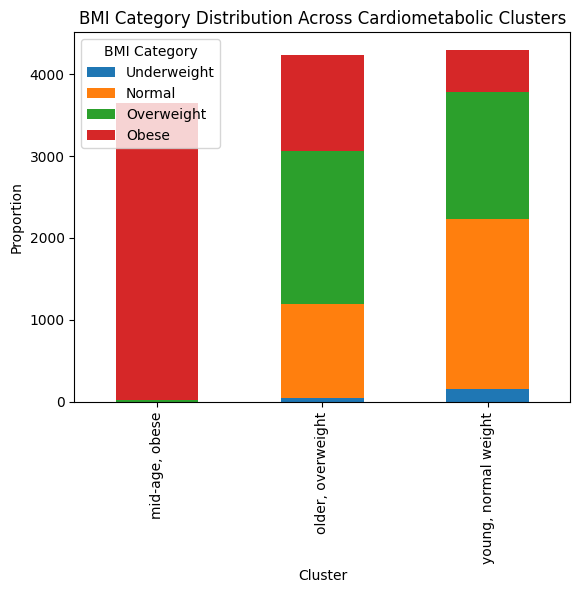

In [ ]:
bmi_cluster.plot(kind='bar', stacked=True)
plt.ylabel("Proportion")
plt.title("BMI Category Distribution Across Cardiometabolic Clusters")
plt.legend(title="BMI Category")
plt.show()

### Clusters with Menopause

In [ ]:
combined["Menopause"] = (
    (combined["Reason not having regular periods"] == 7)
).astype(int)

In [ ]:
meno_cluster = pd.crosstab(combined['Cluster'], combined['Menopause'])
print(meno_cluster)

Menopause                0     1
Cluster                         
mid-age, obese        2653   994
older, overweight     1780  2450
young, normal weight  3722   572


In [ ]:
chi2, p, dof, expected = chi2_contingency(meno_cluster)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 1994.7067802088316
p-value: 0.0


In [ ]:
meno_cluster_pct = pd.crosstab(
    combined['Cluster'],
    combined['Menopause'],
    normalize='index'
) * 100

meno_cluster_pct

Menopause,0,1
Cluster,,
"mid-age, obese",72.744722,27.255278
"older, overweight",42.080378,57.919622
"young, normal weight",86.679087,13.320913


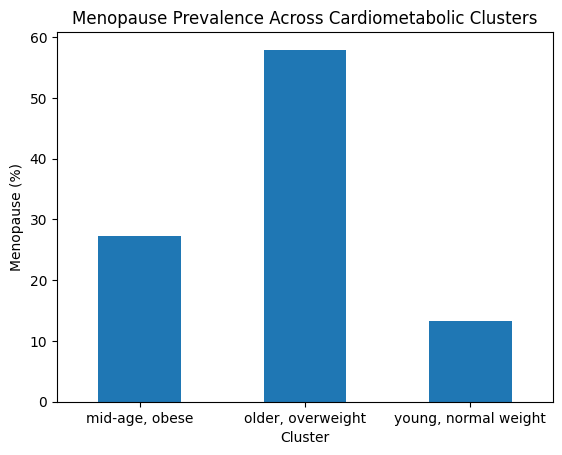

In [ ]:
meno_cluster_pct[1].plot(kind='bar')

plt.title("Menopause Prevalence Across Cardiometabolic Clusters")
plt.xlabel("Cluster")
plt.ylabel("Menopause (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
meno_bmi = pd.crosstab(combined['BMI_Category'], combined['Menopause'],normalize='index'
) * 100
meno_bmi

Menopause,0,1
BMI_Category,,
Underweight,71.500000,28.500000
Normal,68.038366,31.961634
Overweight,63.055475,36.944525
Obese,68.768882,31.231118


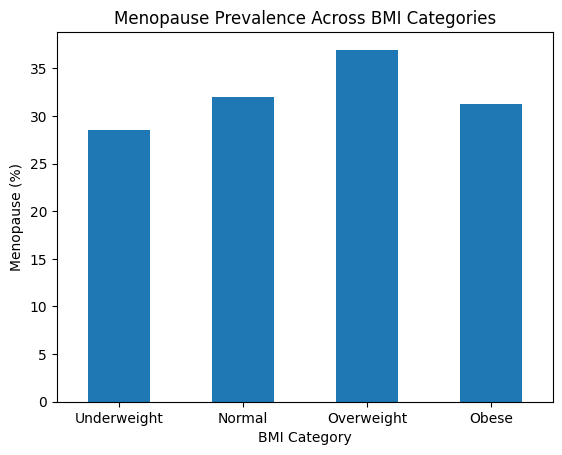

In [ ]:
meno_bmi_pct = pd.crosstab(
    combined['BMI_Category'],
    combined['Menopause'],
    normalize='index'
) * 100

meno_bmi_pct[1].plot(kind='bar')

plt.title("Menopause Prevalence Across BMI Categories")
plt.xlabel("BMI Category")
plt.ylabel("Menopause (%)")
plt.xticks(rotation=0)
plt.show()

## ANOVA

Clusters with Age

In [ ]:
cluster0 = combined[combined['Cluster'] == 0]['age']
cluster1 = combined[combined['Cluster'] == 1]['age']
cluster2 = combined[combined['Cluster'] == 2]['age']

f_stat, p_val = f_oneway(cluster0, cluster1, cluster2)

print("F-statistic:", f_stat)
print("p-value:", p_val)

F-statistic: nan
p-value: nan


/tmp/ipykernel_8159/2605074844.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(cluster0, cluster1, cluster2)


In [ ]:
combined.groupby('Cluster')['age'].mean()

,age
Cluster,
"mid-age, obese",48.508911
"older, overweight",65.468558
"young, normal weight",38.513507


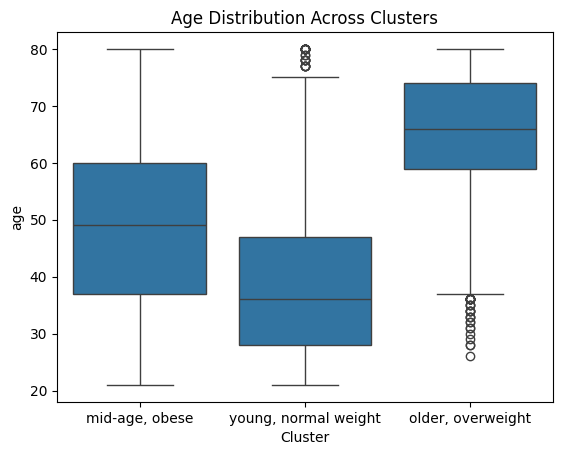

In [ ]:
sns.boxplot(x='Cluster', y='age', data=combined)
plt.title("Age Distribution Across Clusters")
plt.show()

# **Reproductive Variables Dataset**

In [ ]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12171 entries, 3 to 56887
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   12171 non-null  float64 
 1   gender                                 12171 non-null  float64 
 2   age                                    12171 non-null  float64 
 3   race                                   12171 non-null  float64 
 4   weight(kg)                             12171 non-null  float64 
 5   height(cm)                             12171 non-null  float64 
 6   BMI                                    12171 non-null  float64 
 7   Arm Circumference(cm)                  12171 non-null  float64 
 8   Waist Circumference (cm)               12171 non-null  float64 
 9   Had regular periods in past 12 months  12171 non-null  float64 
 10  Reason not having regular periods      6920 non-null   float64 

In [ ]:
combined['Ever been pregnant?'].value_counts()

,count
Ever been pregnant?,
1.0,9202
2.0,1822
7.0,5
9.0,4


In [ ]:
#Cleans column from Unknowns
#Changes repro variables "unknown" vales as NaN
combined[['Had regular periods in past 12 months',
           'Tried for a year to become pregnant?',
           'Ever been pregnant?',
          ]] = combined[['Had regular periods in past 12 months',
                                         'Tried for a year to become pregnant?',
                                         'Ever been pregnant?'
          ]].replace([7, 9, 77, 99], np.nan)

combined[['Reason not having regular periods',
           'age at menarche'
          ]] = combined[['Reason not having regular periods',
                                         'age at menarche'
                         ]].replace([77, 99, 777,999], np.nan)

combined[['number pregnancies']] = combined[['number pregnancies']].replace([12,13,15,16,18,25,77],np.nan)
combined[['live births']] = combined[['live births']].replace([77],np.nan)
combined['live births'] = pd.to_numeric(combined['live births'], errors='coerce')
combined['live births'] = combined['live births'].round(0)


In [ ]:
combined['live births'].value_counts(dropna = False)

,count
live births,
NaN,4378
2.0,2638
3.0,1840
1.0,1524
4.0,1003
5.0,497
6.0,108
7.0,70
8.0,33


In [ ]:
combined['Ever been pregnant?'].value_counts(dropna = False)

,count
Ever been pregnant?,
1.0,9202
2.0,1822
NaN,1147


In [ ]:
def conditional_fill(df, condition_col, condition_val, target_col, fill_val):
  for i in df.index:
    condition_value = df.at[i, condition_col]
    target_value = df.at[i, target_col]

    if condition_value == condition_val:
      if pd.isna(target_value):
        df.at[i, target_col] = fill_val

  return df

In [ ]:
combined = conditional_fill(
    combined,
    condition_col='Had regular periods in past 12 months',
    condition_val=1,
    target_col='Reason not having regular periods',
    #Created 8 which means "Not Applicable"
    fill_val=8
)

#converts 77 & 99 to nan
combined['Reason not having regular periods'] = combined['Reason not having regular periods'].replace([77, 99], np.nan)
combined['Reason not having regular periods'].value_counts(dropna=False)

,count
Reason not having regular periods,
8.0,5242
7.0,4016
3.0,2321
9.0,486
1.0,49
NaN,30
2.0,27


In [ ]:
combined = conditional_fill(
    combined,
    condition_col='Ever been pregnant?',
    condition_val=2,
    target_col='live births',
    #Created 8 which means "Not Applicable"
    fill_val=0
)

combined['live births'].value_counts(dropna=False)

,count
live births,
2.0,2638
NaN,2556
0.0,1851
3.0,1840
1.0,1524
4.0,1003
5.0,497
6.0,108
7.0,70


In [ ]:
combined = conditional_fill(
    combined,
    condition_col='Ever been pregnant?',
    condition_val=2,
    target_col='number pregnancies',
    #Created 0 which means "Not Applicable"
    fill_val=0
)

combined['number pregnancies'].value_counts(dropna=False)

,count
number pregnancies,
NaN,2144
2.0,1975
3.0,1904
0.0,1822
4.0,1352
1.0,1048
5.0,909
6.0,440
7.0,272


In [ ]:
#Drops nan Values from reproductive Variables
combined = combined.dropna(subset=['Reason not having regular periods',
                                   'Tried for a year to become pregnant?',
                                   'age at menarche',
                                   'number pregnancies',
                                   'live births'
                                   ])

In [ ]:
combined['Ever been pregnant?'].value_counts(dropna=False)

,count
Ever been pregnant?,
1.0,4831
2.0,1223


In [ ]:
combined['age at menarche'].value_counts(dropna=False)

,count
age at menarche,
12.0,1590
13.0,1416
11.0,833
14.0,742
15.0,435
10.0,352
16.0,278
9.0,239
17.0,79


In [ ]:
combined["Infertile"] = combined["Tried for a year to become pregnant?"].map({1:1, 2:0})
combined["Infertile"].value_counts()

,count
Infertile,
0,5389
1,665


In [ ]:
#Dataset is Fully Clean
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6054 entries, 3 to 56880
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   6054 non-null   float64 
 1   gender                                 6054 non-null   float64 
 2   age                                    6054 non-null   float64 
 3   race                                   6054 non-null   float64 
 4   weight(kg)                             6054 non-null   float64 
 5   height(cm)                             6054 non-null   float64 
 6   BMI                                    6054 non-null   float64 
 7   Arm Circumference(cm)                  6054 non-null   float64 
 8   Waist Circumference (cm)               6054 non-null   float64 
 9   Had regular periods in past 12 months  6054 non-null   float64 
 10  Reason not having regular periods      6054 non-null   float64 


In [ ]:
#Creates an infertility dataset which is the above dataset just filtered down to women less than 50
inf_df = combined[
    (combined["age"] <= 49)
].copy()

inf_df.shape

(4431, 24)

In [ ]:
inf_df

,SEQN,gender,age,race,weight(kg),height(cm),BMI,Arm Circumference(cm),Waist Circumference (cm),Had regular periods in past 12 months,...,number pregnancies,live births,HDL,Systolic BP,Diastolic BP,BMI_Category,Cluster,race_label,Menopause,Infertile
4,83736.0,2.0,42.0,4.0,55.2,164.9,20.3,27.2,80.4,1.0,...,7.0,5.0,53.0,100.0,70.0,Normal,"young, normal weight",Non-Hispanic Black,0,0
10,83742.0,2.0,32.0,1.0,64.5,151.3,28.2,31.5,93.3,1.0,...,3.0,3.0,28.0,120.0,70.0,Overweight,"young, normal weight",Mexican American,0,0
20,83752.0,2.0,30.0,2.0,71.2,163.6,26.6,31.0,90.7,1.0,...,0.0,0.0,67.0,104.0,50.0,Overweight,"young, normal weight",Other Hispanic,0,0
29,83761.0,2.0,24.0,5.0,61.8,156.4,25.3,29.6,79.5,1.0,...,0.0,0.0,41.0,110.0,62.0,Overweight,"young, normal weight",Other,0,0
49,83781.0,2.0,27.0,4.0,87.8,160.7,34.0,32.1,103.6,1.0,...,0.0,0.0,54.0,108.0,66.0,Obese,"young, normal weight",Non-Hispanic Black,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56839,124769.0,2.0,28.0,5.0,54.3,148.8,24.5,25.8,79.7,1.0,...,0.0,0.0,54.0,84.0,57.0,Normal,"young, normal weight",Other,0,0
56841,124771.0,2.0,25.0,3.0,62.7,167.7,22.3,27.8,74.7,1.0,...,0.0,0.0,61.0,110.0,70.0,Normal,"young, normal weight",Non-Hispanic White,0,0
56850,124780.0,2.0,36.0,3.0,84.6,172.7,28.4,31.3,102.9,1.0,...,7.0,4.0,71.0,102.0,65.0,Overweight,"young, normal weight",Non-Hispanic White,0,0
56872,124802.0,2.0,46.0,5.0,57.0,160.8,22.0,27.8,80.0,1.0,...,2.0,2.0,38.0,145.0,92.0,Normal,"older, overweight",Other,0,0


In [162]:
# file_path = '/content/drive/MyDrive//Colab Notebooks/FYP/InfertilityPred_Dataset.csv'

# inf_df.to_csv(file_path, index=False)

In [ ]:
#Features predictive Features
features = [
"age",
"BMI",
"Waist Circumference (cm)",
"Arm Circumference(cm)",
"Systolic BP",
"Diastolic BP",
"HDL",
"Had regular periods in past 12 months",
"age at menarche",
"number pregnancies",
"live births", "Infertile"
]

inf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4431 entries, 4 to 56879
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   4431 non-null   float64 
 1   gender                                 4431 non-null   float64 
 2   age                                    4431 non-null   float64 
 3   race                                   4431 non-null   float64 
 4   weight(kg)                             4431 non-null   float64 
 5   height(cm)                             4431 non-null   float64 
 6   BMI                                    4431 non-null   float64 
 7   Arm Circumference(cm)                  4431 non-null   float64 
 8   Waist Circumference (cm)               4431 non-null   float64 
 9   Had regular periods in past 12 months  4431 non-null   float64 
 10  Reason not having regular periods      4431 non-null   float64 


# **EDA**

## 1. What does my dataset look like?

In [ ]:
print(f'infertility dataset shape ', inf_df.shape)
print(f'NaN Values in Infertility dataset:\n ', inf_df.isnull().sum())
print(f'clustering dataset shape ', cluster_df.shape)
print(f'NaN Values in Cluster dataset:\n ', cluster_df.isnull().sum())

infertility dataset shape  (4431, 24)
NaN Values in Infertility dataset:
  SEQN                                     0
gender                                   0
age                                      0
race                                     0
weight(kg)                               0
height(cm)                               0
BMI                                      0
Arm Circumference(cm)                    0
Waist Circumference (cm)                 0
Had regular periods in past 12 months    0
Reason not having regular periods        0
Tried for a year to become pregnant?     0
Ever been pregnant?                      0
age at menarche                          0
number pregnancies                       0
live births                              0
HDL                                      0
Systolic BP                              0
Diastolic BP                             0
BMI_Category                             0
Cluster                                  0
race_label            

In [ ]:
inf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4431 entries, 4 to 56879
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   4431 non-null   float64 
 1   gender                                 4431 non-null   float64 
 2   age                                    4431 non-null   float64 
 3   race                                   4431 non-null   float64 
 4   weight(kg)                             4431 non-null   float64 
 5   height(cm)                             4431 non-null   float64 
 6   BMI                                    4431 non-null   float64 
 7   Arm Circumference(cm)                  4431 non-null   float64 
 8   Waist Circumference (cm)               4431 non-null   float64 
 9   Had regular periods in past 12 months  4431 non-null   float64 
 10  Reason not having regular periods      4431 non-null   float64 


In [ ]:
cluster_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12171 entries, 3 to 56887
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       12171 non-null  float64
 1   BMI                       12171 non-null  float64
 2   Waist Circumference (cm)  12171 non-null  float64
 3   Arm Circumference(cm)     12171 non-null  float64
 4   Systolic BP               12171 non-null  float64
 5   Diastolic BP              12171 non-null  float64
 6   HDL                       12171 non-null  float64
 7   KMeans_Cluster            12171 non-null  int32  
 8   GMM_Cluster               12171 non-null  int64  
 9   Hier_Cluster              12171 non-null  int64  
dtypes: float64(7), int32(1), int64(2)
memory usage: 1.2 MB


In [ ]:
inf_df.describe()

,SEQN,gender,age,race,weight(kg),height(cm),BMI,Arm Circumference(cm),Waist Circumference (cm),Had regular periods in past 12 months,...,Tried for a year to become pregnant?,Ever been pregnant?,age at menarche,number pregnancies,live births,HDL,Systolic BP,Diastolic BP,Menopause,Infertile
count,4431.000000,4431.0,4431.000000,4431.000000,4431.000000,4431.000000,4431.000000,4431.000000,4431.000000,4431.000000,...,4431.00000,4431.000000,4431.000000,4431.000000,4431.000000,4431.000000,4431.000000,4.431000e+03,4431.000000,4431.00000
mean,97632.655608,2.0,35.224103,3.146694,78.886820,161.559923,30.140781,32.904288,97.303995,1.139698,...,1.88603,1.241706,12.516136,2.502144,1.818551,56.195441,113.614308,7.071654e+01,0.023922,0.11397
std,15503.747118,0.0,8.332081,1.284800,23.134517,6.951728,8.253859,5.872536,18.483157,0.346712,...,0.31781,0.428165,1.769990,2.111867,1.490838,15.638168,14.053910,1.163871e+01,0.152825,0.31781
min,73568.000000,2.0,21.000000,1.000000,36.900000,137.600000,14.600000,19.000000,58.700000,1.000000,...,1.00000,1.000000,6.000000,0.000000,0.000000,16.000000,74.000000,5.397605e-79,0.000000,0.00000
25%,84257.000000,2.0,28.000000,2.000000,61.800000,156.800000,23.900000,28.550000,83.100000,1.000000,...,2.00000,1.000000,11.000000,1.000000,1.000000,45.000000,104.000000,6.400000e+01,0.000000,0.00000
50%,94936.000000,2.0,35.000000,3.000000,74.200000,161.600000,28.700000,32.100000,94.400000,1.000000,...,2.00000,1.000000,12.000000,2.000000,2.000000,54.000000,112.000000,7.000000e+01,0.000000,0.00000
75%,113048.000000,2.0,42.000000,4.000000,91.850000,166.300000,34.800000,36.500000,108.500000,1.000000,...,2.00000,1.000000,13.000000,4.000000,3.000000,65.000000,120.000000,7.800000e+01,0.000000,0.00000
max,124809.000000,2.0,49.000000,5.000000,184.800000,189.300000,67.000000,58.400000,178.000000,2.000000,...,2.00000,2.000000,20.000000,11.000000,9.000000,178.000000,216.000000,1.290000e+02,1.000000,1.00000


In [ ]:
cluster_df.describe()

,age,BMI,Waist Circumference (cm),Arm Circumference(cm),Systolic BP,Diastolic BP,HDL,KMeans_Cluster,GMM_Cluster,Hier_Cluster
count,12171.000000,12171.000000,12171.000000,12171.00000,12171.000000,1.217100e+04,12171.000000,12171.000000,12171.000000,12171.000000
mean,50.876756,30.118404,99.061039,32.70129,122.506943,7.182039e+01,58.357078,1.049544,1.075672,0.634870
std,17.021460,7.710923,17.153450,5.52449,19.620684,1.249983e+01,16.305284,0.804115,0.773180,0.723327
min,21.000000,14.200000,58.700000,17.10000,66.000000,5.397605e-79,5.000000,0.000000,0.000000,0.000000
25%,36.000000,24.500000,86.500000,28.70000,108.000000,6.400000e+01,47.000000,0.000000,0.000000,0.000000
50%,52.000000,28.800000,97.500000,32.00000,119.000000,7.200000e+01,56.000000,1.000000,1.000000,0.000000
75%,64.000000,34.400000,109.700000,36.00000,134.000000,7.900000e+01,67.000000,2.000000,2.000000,1.000000
max,80.000000,80.600000,187.500000,59.40000,228.000000,1.420000e+02,226.000000,2.000000,2.000000,2.000000


## 2. Are my numerical variables well-behaved?

In [ ]:
#Select numerical columns
num_cols = ['age', 'BMI', 'weight(kg)', 'height(cm)',"Waist Circumference (cm)","Arm Circumference(cm)","Systolic BP", "Diastolic BP", "HDL", "age at menarche" , "number pregnancies", "live births" ]

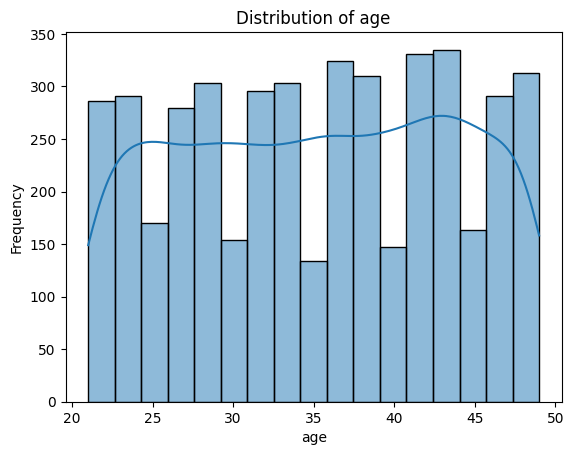

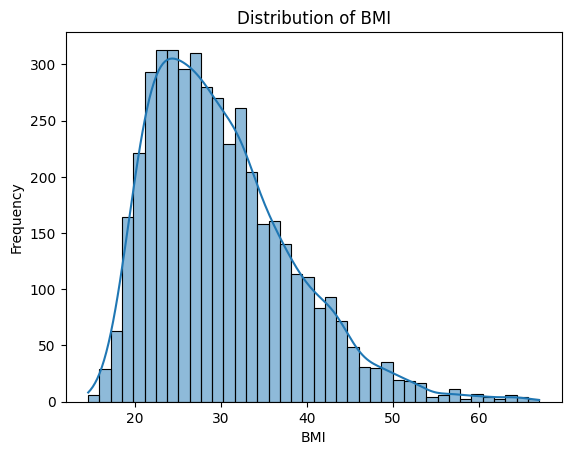

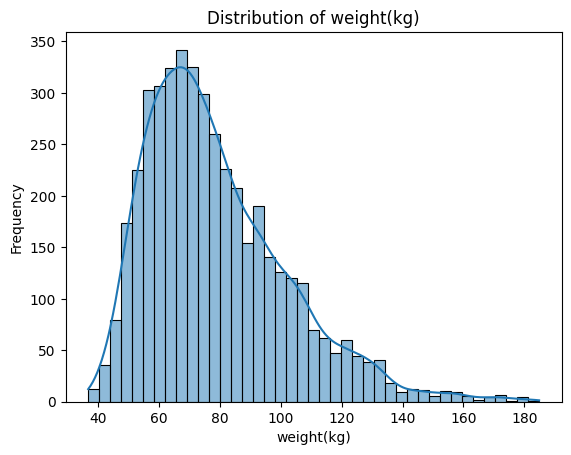

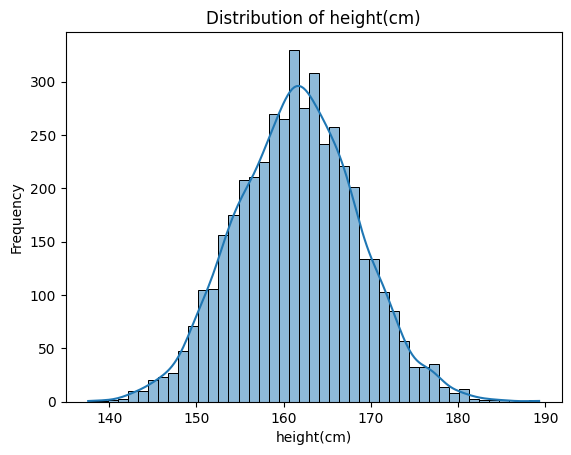

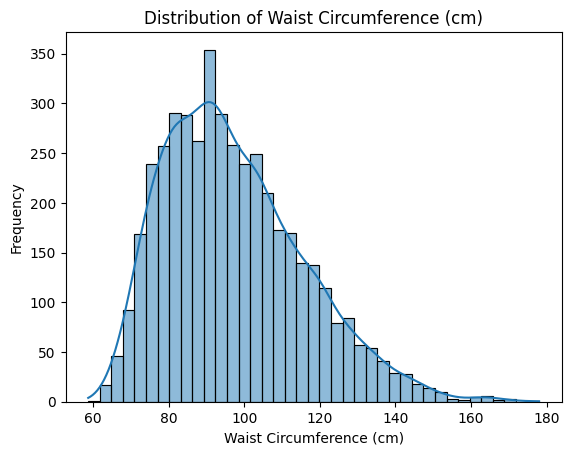

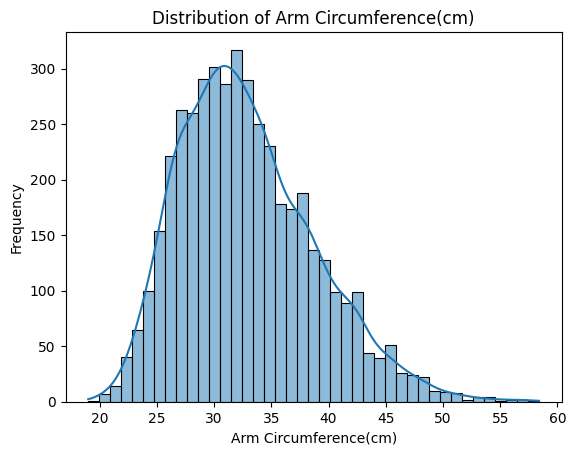

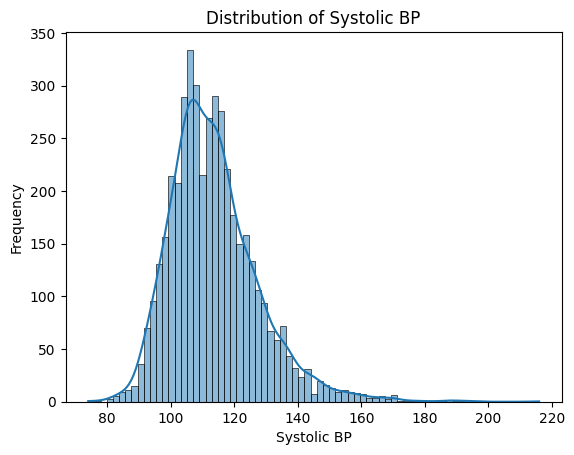

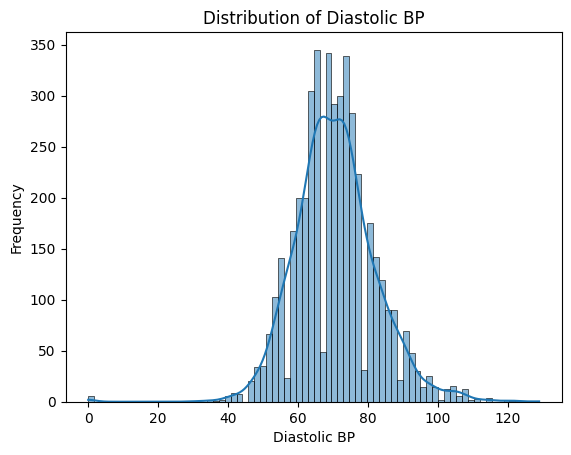

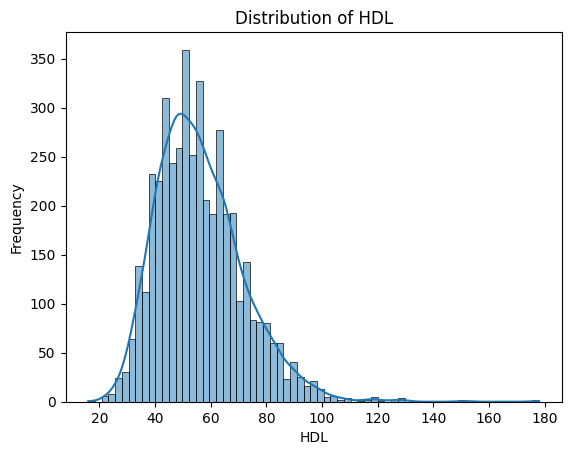

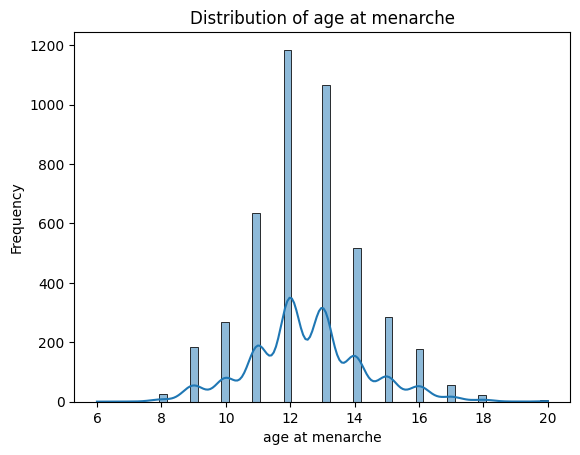

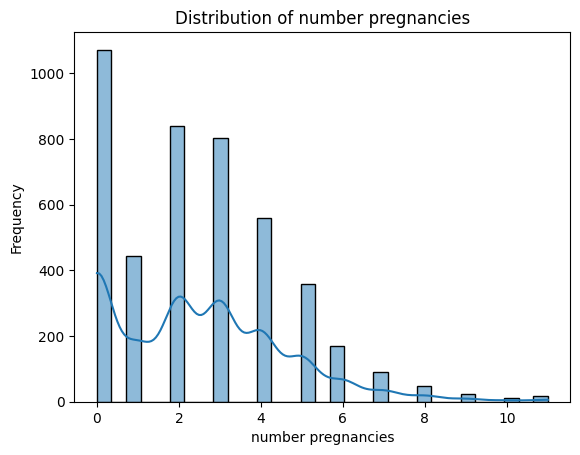

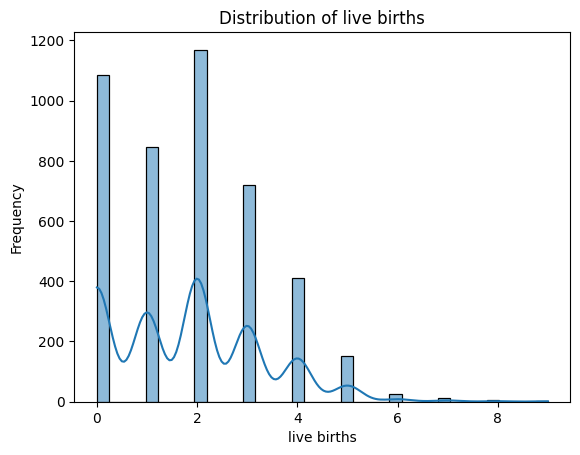

In [ ]:
#Historical
for col in num_cols:
    plt.figure()
    sns.histplot(data=inf_df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## 3. Are variables related?

,age,BMI,Waist Circumference (cm),Arm Circumference(cm),Systolic BP,Diastolic BP,HDL,Had regular periods in past 12 months,age at menarche,number pregnancies,live births,Infertile
age,1.000000,0.119920,0.156868,0.123395,0.289651,0.281353,0.014584,0.229207,0.055692,0.402076,0.422021,0.059743
BMI,0.119920,1.000000,0.940109,0.931399,0.259829,0.238796,-0.362328,0.038104,-0.194106,0.125356,0.103416,0.081089
Waist Circumference (cm),0.156868,0.940109,1.000000,0.884869,0.275521,0.253612,-0.361925,0.068281,-0.162332,0.151520,0.132494,0.100151
Arm Circumference(cm),0.123395,0.931399,0.884869,1.000000,0.258628,0.242097,-0.357959,0.044917,-0.177526,0.135967,0.116282,0.065813
Systolic BP,0.289651,0.259829,0.275521,0.258628,1.000000,0.651918,-0.084561,0.064753,-0.048149,0.110746,0.108803,0.021316
Diastolic BP,0.281353,0.238796,0.253612,0.242097,0.651918,1.000000,-0.061068,0.076328,-0.037768,0.105492,0.094763,0.035710
HDL,0.014584,-0.362328,-0.361925,-0.357959,-0.084561,-0.061068,1.000000,-0.035929,0.084016,-0.075957,-0.081485,-0.060303
Had regular periods in past 12 months,0.229207,0.038104,0.068281,0.044917,0.064753,0.076328,-0.035929,1.000000,-0.014893,0.081442,0.098399,-0.015461
age at menarche,0.055692,-0.194106,-0.162332,-0.177526,-0.048149,-0.037768,0.084016,-0.014893,1.000000,-0.025629,-0.003937,-0.023535
number pregnancies,0.402076,0.125356,0.151520,0.135967,0.110746,0.105492,-0.075957,0.081442,-0.025629,1.000000,0.861631,0.032764


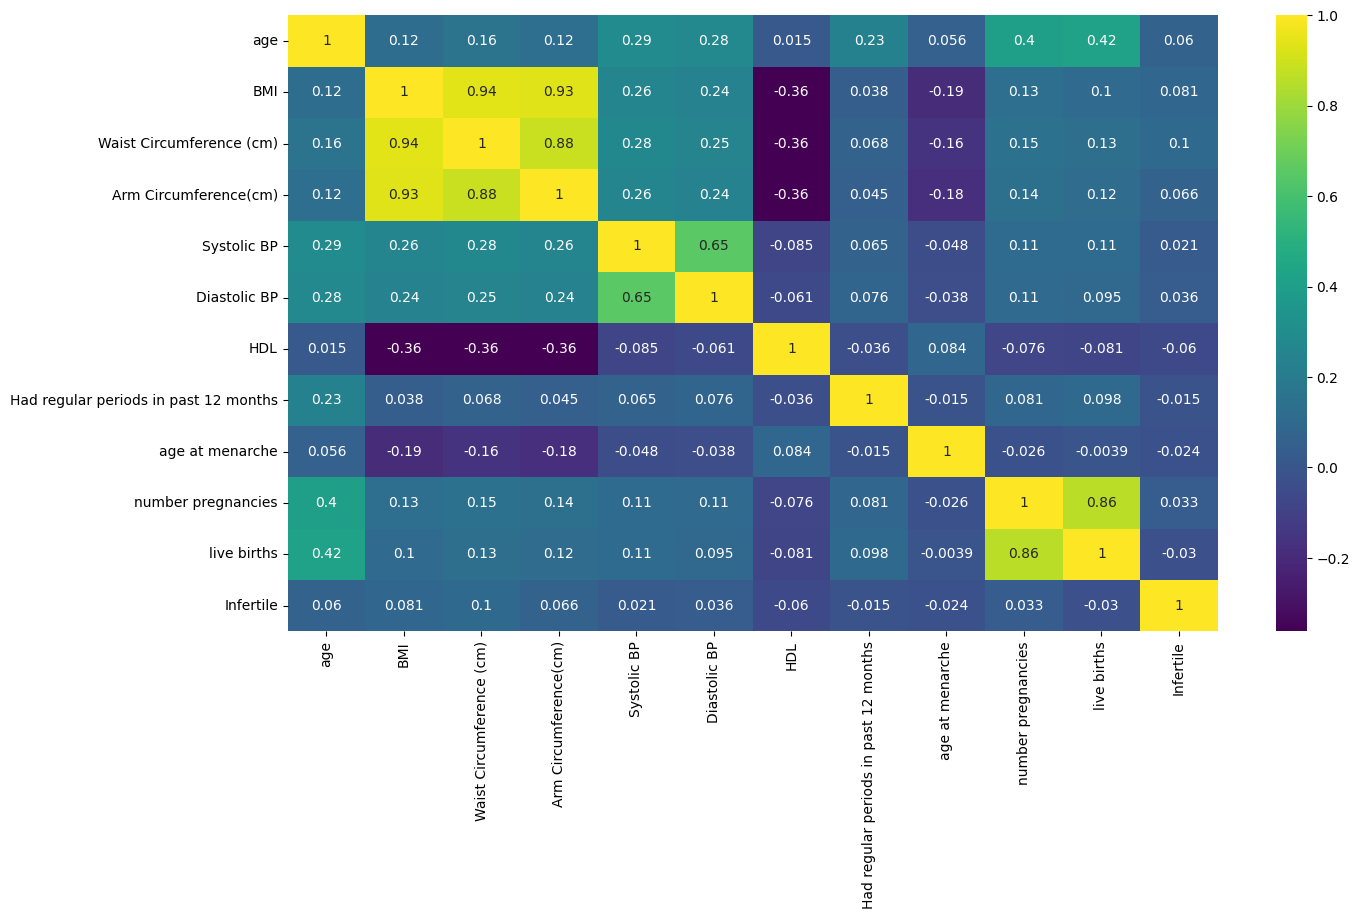

In [ ]:
features = [
"age",
"BMI",
"Waist Circumference (cm)",
"Arm Circumference(cm)", #remove due to multicolinarity
"Systolic BP",
"Diastolic BP",
"HDL",
"Had regular periods in past 12 months",
"age at menarche",
"number pregnancies",
"live births", "Infertile"
]

corr = inf_df[features].corr()
plt.figure(figsize=(15,8))
sns.heatmap(corr, \
            xticklabels=corr.columns.values,\
            yticklabels=corr.columns.values,\
            annot=True,cmap='viridis')
corr

## 4. What do categorical variables look like?

In [ ]:
cat_cols = [
    'Had regular periods in past 12 months',
    'Reason not having regular periods',
    'Tried for a year to become pregnant?',
    'Ever been pregnant?',
    'Menopause'
]

In [ ]:
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(inf_df[col].value_counts())


Value counts for Had regular periods in past 12 months:
Had regular periods in past 12 months
1.0    3812
2.0     619
Name: count, dtype: int64

Value counts for Reason not having regular periods:
Reason not having regular periods
8.0    3812
3.0     251
9.0     198
7.0     106
1.0      43
2.0      21
Name: count, dtype: int64

Value counts for Tried for a year to become pregnant?:
Tried for a year to become pregnant?
2.0    3926
1.0     505
Name: count, dtype: int64

Value counts for Ever been pregnant?:
Ever been pregnant?
1.0    3360
2.0    1071
Name: count, dtype: int64

Value counts for Menopause:
Menopause
0    4325
1     106
Name: count, dtype: int64


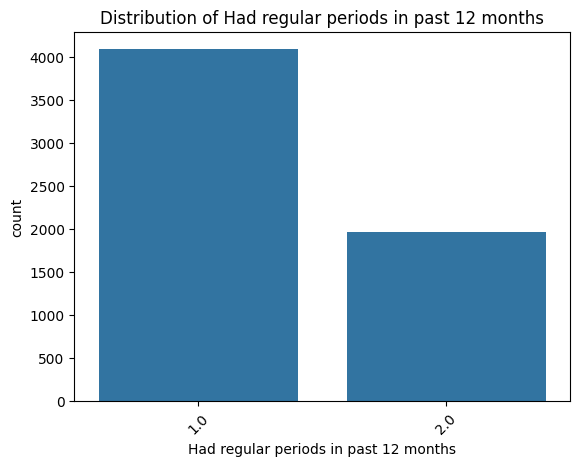

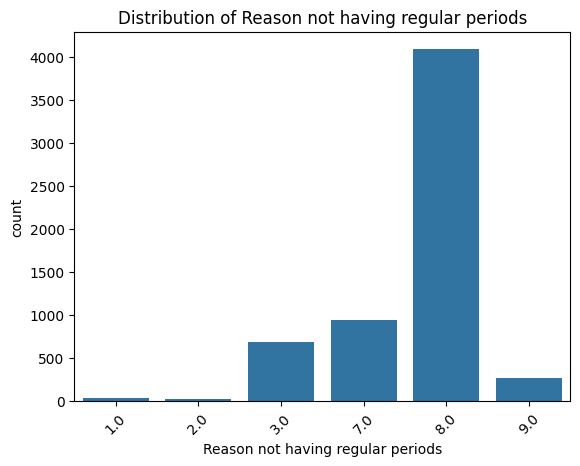

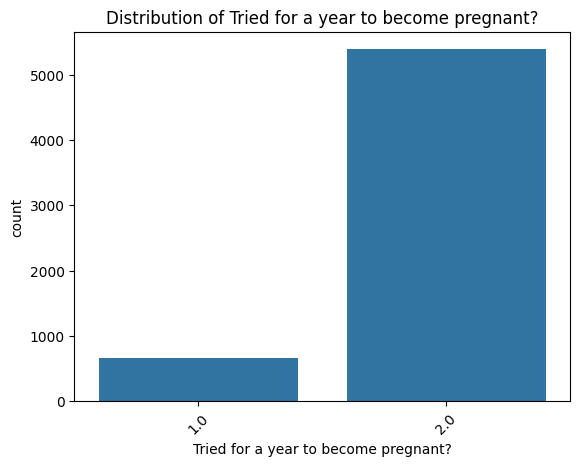

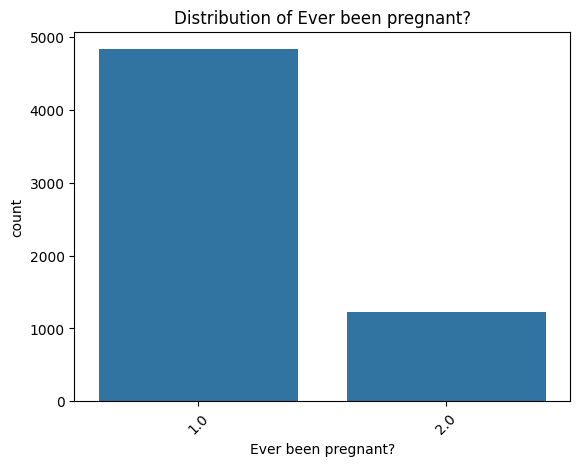

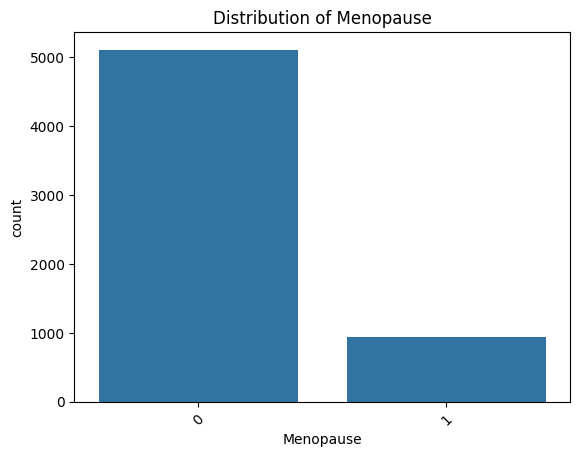

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_cols:
    plt.figure()
    sns.countplot(data=combined, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
inf_df['Ever been pregnant?'].value_counts()

,count
Ever been pregnant?,
1.0,3360
2.0,1071


In [ ]:
for col in cat_cols:
    print(f"\nPercentage distribution for {col}:")
    print(inf_df[col].value_counts(normalize=True) * 100)


Percentage distribution for Had regular periods in past 12 months:
Had regular periods in past 12 months
1.0    86.030241
2.0    13.969759
Name: proportion, dtype: float64

Percentage distribution for Reason not having regular periods:
Reason not having regular periods
8.0    86.030241
3.0     5.664636
9.0     4.468517
7.0     2.392237
1.0     0.970436
2.0     0.473934
Name: proportion, dtype: float64

Percentage distribution for Tried for a year to become pregnant?:
Tried for a year to become pregnant?
2.0    88.603024
1.0    11.396976
Name: proportion, dtype: float64

Percentage distribution for Ever been pregnant?:
Ever been pregnant?
1.0    75.829384
2.0    24.170616
Name: proportion, dtype: float64

Percentage distribution for Menopause:
Menopause
0    97.607763
1     2.392237
Name: proportion, dtype: float64


## Infertility EDA

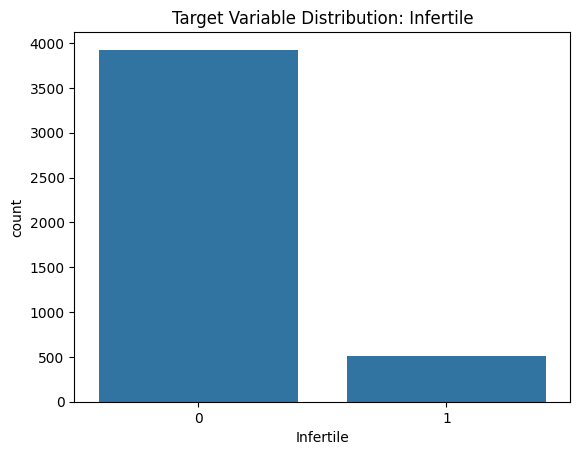

In [ ]:
target_cols = [
    'Infertile'
]

for col in target_cols:
    plt.figure()
    sns.countplot(data=inf_df, x=col)
    plt.title(f'Target Variable Distribution: {col}')
    plt.show()

In [ ]:
print(inf_df['Infertile'].value_counts(normalize=True) * 100)

Infertile
0    88.603024
1    11.396976
Name: proportion, dtype: float64


Cluster distribution of Infertility

In [ ]:
cluster_dist = pd.crosstab(inf_df['Cluster'], inf_df['Infertile'], normalize='index')
cluster_dist.columns = ["Not Infertile", "Infertile"]
cluster_dist = cluster_dist.round(3)

cluster_dist

,Not Infertile,Infertile
Cluster,,
"mid-age, obese",0.843,0.157
"older, overweight",0.897,0.103
"young, normal weight",0.910,0.090


Compare variables by infertility

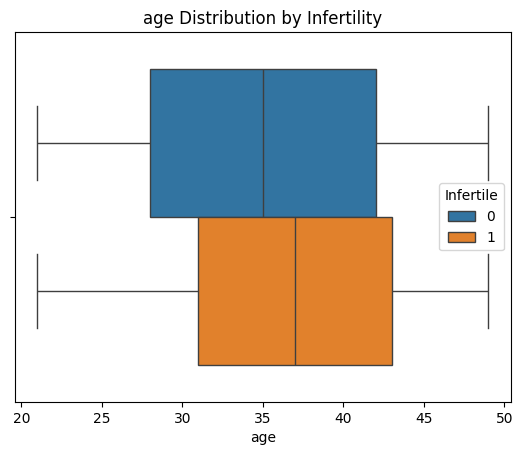

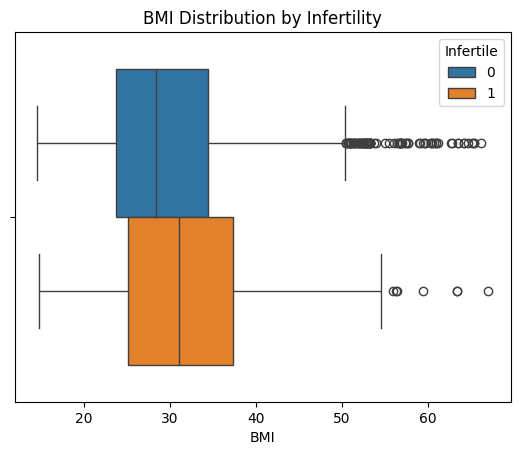

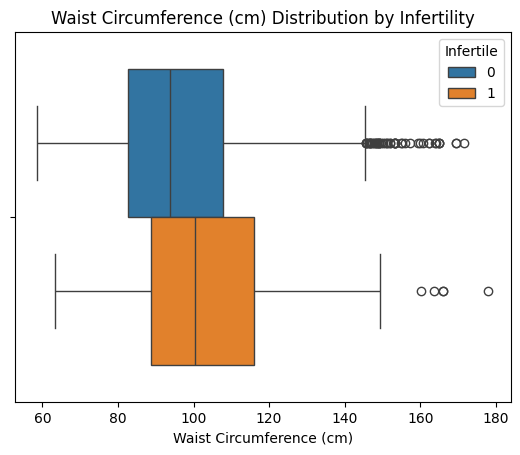

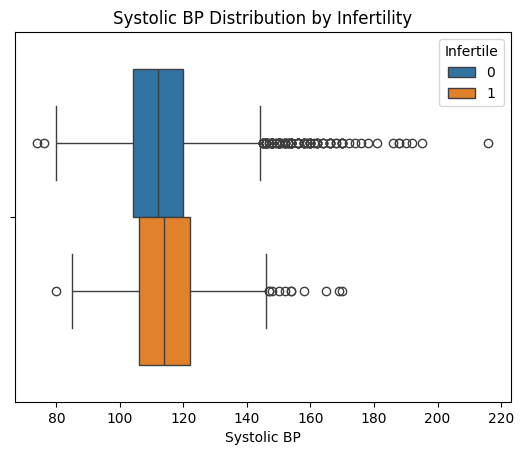

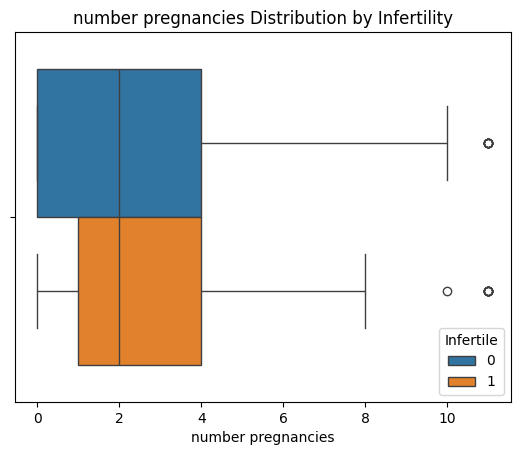

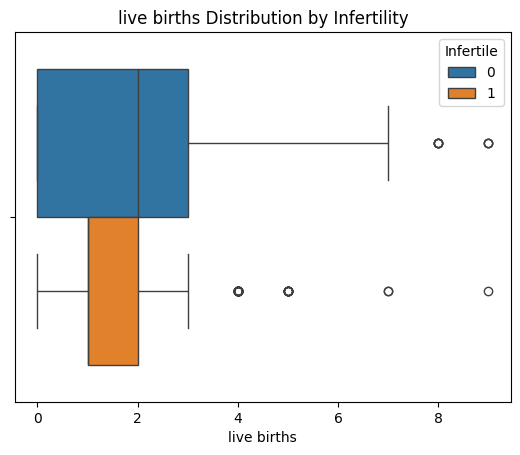

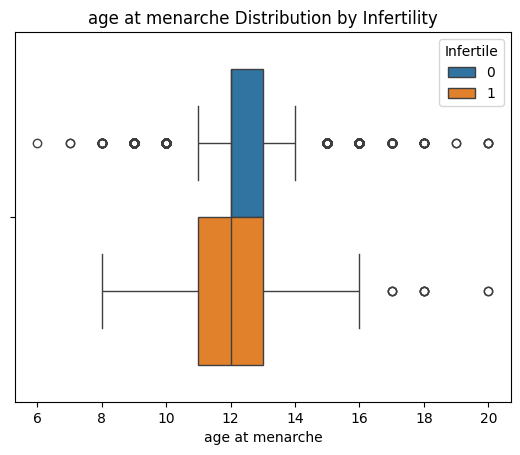

In [ ]:
for col in ["age", "BMI", "Waist Circumference (cm)", "Systolic BP","number pregnancies", "live births", "age at menarche"]:
    sns.boxplot(data=inf_df, x=col, hue="Infertile", fill=True)
    plt.title(f"{col} Distribution by Infertility")
    plt.show()

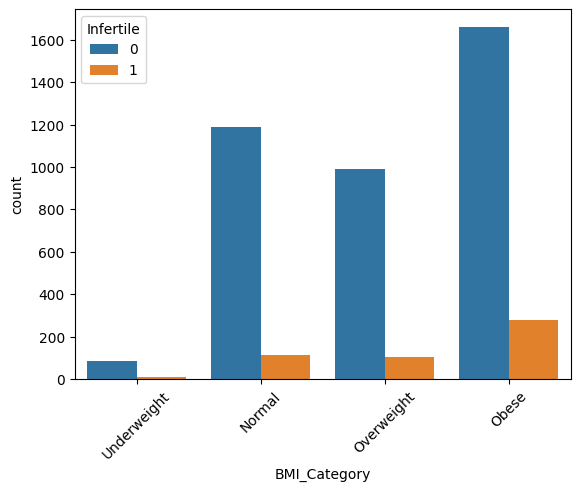

In [ ]:
sns.countplot(data= inf_df, x="BMI_Category", hue="Infertile")
plt.xticks(rotation=45)
plt.show()

BMI Categories EDA

# **Infertility**

## Distribution of Infertility across Clusters

In [ ]:
#predictive Features
features = [
"age",
"BMI",
"Waist Circumference (cm)",
#"Arm Circumference(cm)", remove due to multicolinarity as seen in EDA
"Systolic BP",
"Diastolic BP",
"HDL",
"Had regular periods in past 12 months",
"age at menarche",
"number pregnancies",
"live births",
]

inf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4431 entries, 4 to 56879
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   4431 non-null   float64 
 1   gender                                 4431 non-null   float64 
 2   age                                    4431 non-null   float64 
 3   race                                   4431 non-null   float64 
 4   weight(kg)                             4431 non-null   float64 
 5   height(cm)                             4431 non-null   float64 
 6   BMI                                    4431 non-null   float64 
 7   Arm Circumference(cm)                  4431 non-null   float64 
 8   Waist Circumference (cm)               4431 non-null   float64 
 9   Had regular periods in past 12 months  4431 non-null   float64 
 10  Reason not having regular periods      4431 non-null   float64 


In [ ]:
#Balance of Infertility against Clusters
cluster_dist = pd.crosstab(inf_df['Cluster'], inf_df['Infertile'], normalize='index')
cluster_dist.columns = ["Not Infertile", "Infertile"]
cluster_dist = cluster_dist.round(3)

cluster_dist

,Not Infertile,Infertile
Cluster,,
"mid-age, obese",0.843,0.157
"older, overweight",0.897,0.103
"young, normal weight",0.910,0.090


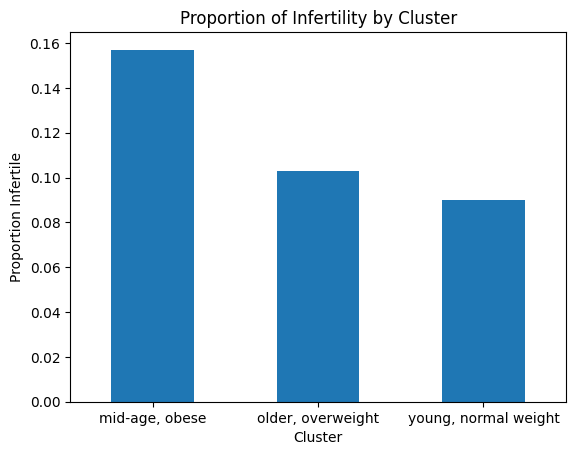

In [ ]:
cluster_dist.columns = ["Not Infertile", "Infertile"]

cluster_dist["Infertile"].plot(kind="bar")
plt.title("Proportion of Infertility by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion Infertile")
plt.xticks(rotation=0)
plt.show()

Mid-age obese has the highest number of infertile positve cases, however the differences are not huge 15.7% to 10.9%

In [ ]:
inf_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4431 entries, 4 to 56879
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   SEQN                                   4431 non-null   float64 
 1   gender                                 4431 non-null   float64 
 2   age                                    4431 non-null   float64 
 3   race                                   4431 non-null   float64 
 4   weight(kg)                             4431 non-null   float64 
 5   height(cm)                             4431 non-null   float64 
 6   BMI                                    4431 non-null   float64 
 7   Arm Circumference(cm)                  4431 non-null   float64 
 8   Waist Circumference (cm)               4431 non-null   float64 
 9   Had regular periods in past 12 months  4431 non-null   float64 
 10  Reason not having regular periods      4431 non-null   float64 


In [ ]:
inf_df[features]

,age,BMI,Waist Circumference (cm),Systolic BP,Diastolic BP,HDL,Had regular periods in past 12 months,age at menarche,number pregnancies,live births
4,42.0,20.3,80.4,100.0,70.0,53.0,1.0,13.0,7.0,5.0
10,32.0,28.2,93.3,120.0,70.0,28.0,1.0,13.0,3.0,3.0
20,30.0,26.6,90.7,104.0,50.0,67.0,1.0,11.0,0.0,0.0
29,24.0,25.3,79.5,110.0,62.0,41.0,1.0,12.0,0.0,0.0
49,27.0,34.0,103.6,108.0,66.0,54.0,1.0,14.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
56839,28.0,24.5,79.7,84.0,57.0,54.0,1.0,13.0,0.0,0.0
56841,25.0,22.3,74.7,110.0,70.0,61.0,1.0,11.0,0.0,0.0
56850,36.0,28.4,102.9,102.0,65.0,71.0,1.0,13.0,7.0,4.0
56872,46.0,22.0,80.0,145.0,92.0,38.0,1.0,14.0,2.0,2.0


# **Infertility Prediction on Full Dataset**

## **Logistic Regression**

In [ ]:
X1 = inf_df[features]
y = inf_df["Infertile"]

#Split
X_train, X_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.3, random_state=42, stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#Scale
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

#Fit LR Model
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_res, y_train_res)

#Prediction
y_pred_log = model1.predict(X_test)
y_proba_log = model1.predict_proba(X_test)[:, 1]

#Metrics
print("Logistic Regression AUC:", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression AUC: 0.6656688410329729
              precision    recall  f1-score   support

           0       0.93      0.62      0.74      1178
           1       0.17      0.62      0.27       152

    accuracy                           0.62      1330
   macro avg       0.55      0.62      0.51      1330
weighted avg       0.84      0.62      0.69      1330



## **Random Forest**

In [ ]:
X_rf = inf_df[features]
y = inf_df["Infertile"]

#Split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_rf_res, y_train_rf_res = smote.fit_resample(X_train_rf, y_train_rf)

#Fit RF Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_rf_res, y_train_rf_res)

#Prediction
y_pred_rf = rf_model.predict(X_test_rf)
y_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]

#Metrics
print("Random Forest AUC:", roc_auc_score(y_test_rf, y_proba_rf))
print(classification_report(y_test_rf, y_pred_rf))

Random Forest AUC: 0.7228101822893398
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1178
           1       0.60      0.20      0.30       152

    accuracy                           0.89      1330
   macro avg       0.75      0.59      0.62      1330
weighted avg       0.87      0.89      0.87      1330



## **XGBoost**

In [ ]:
X_xgb = inf_df[features]
y = inf_df["Infertile"]

#Split
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y, test_size=0.3, random_state=42, stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_xgb_res, y_train_xgb_res = smote.fit_resample(X_train_xgb, y_train_xgb)

#Fit XGBoost Model
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1)
xgb_model.fit(X_train_xgb_res, y_train_xgb_res)

#Prediction
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

#Metrics
print("XGBoost AUC:", roc_auc_score(y_test_xgb, y_proba_xgb))
print(classification_report(y_test_xgb, y_pred_xgb))

XGBoost AUC: 0.7034223929943705
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1178
           1       0.42      0.18      0.25       152

    accuracy                           0.88      1330
   macro avg       0.66      0.57      0.59      1330
weighted avg       0.85      0.88      0.86      1330



## **SVM**

In [ ]:
X_svm = inf_df[features]
y = inf_df["Infertile"]

#Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_svm_res, y_train_svm_res = smote.fit_resample(X_train_svm, y_train_svm)

#Scale
scaler = StandardScaler()
X_train_svm_res = scaler.fit_transform(X_train_svm_res)
X_test_svm = scaler.transform(X_test_svm)

#Fit SVM Model
svm_model = SVC(probability=True, kernel="rbf", random_state=42)
svm_model.fit(X_train_svm_res, y_train_svm_res)

#Prediction
y_pred_svm = svm_model.predict(X_test_svm)
y_proba_svm = svm_model.predict_proba(X_test_svm)[:, 1]

#Metrics
print("SVM AUC:", roc_auc_score(y_test_svm, y_proba_svm))
print(classification_report(y_test_svm, y_pred_svm))

SVM AUC: 0.6689136359574658
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1178
           1       0.20      0.55      0.29       152

    accuracy                           0.69      1330
   macro avg       0.56      0.63      0.55      1330
weighted avg       0.84      0.69      0.74      1330



## **Gradient Boosting**

In [ ]:
X_gb = inf_df[features]
y = inf_df["Infertile"]

#Split
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_gb_res, y_train_gb_res = smote.fit_resample(X_train_gb, y_train_gb)

#Scale
scaler = StandardScaler()
X_train_gb_res = scaler.fit_transform(X_train_gb_res)
X_test_gb = scaler.transform(X_test_gb)

#Fit Gradient boosting Model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_gb_res, y_train_gb_res)

#Prediction
y_pred_gb = gb_model.predict(X_test_gb)
y_proba_gb = gb_model.predict_proba(X_test_gb)[:, 1]

#Metrics
print("Gradient Boosting AUC:", roc_auc_score(y_test_gb, y_proba_gb))
print(classification_report(y_test_gb, y_pred_gb))

Gradient Boosting AUC: 0.6902644982575283
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1178
           1       0.28      0.05      0.09       152

    accuracy                           0.88      1330
   macro avg       0.58      0.52      0.51      1330
weighted avg       0.82      0.88      0.84      1330



## **K-NN**

In [ ]:
X_knn = inf_df[features]
y = inf_df["Infertile"]

# Split
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_knn_res, y_train_knn_res = smote.fit_resample(X_train_knn, y_train_knn)

#Scale
scaler = StandardScaler()
X_train_knn_res = scaler.fit_transform(X_train_knn_res)
X_test_knn = scaler.transform(X_test_knn)

#Fit KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_knn_res, y_train_knn_res)

#Prediction
y_pred_knn = knn_model.predict(X_test_knn)
y_proba_knn = knn_model.predict_proba(X_test_knn)[:, 1]

#Metrics
print("KNN AUC:", roc_auc_score(y_test_knn, y_proba_knn))
print(classification_report(y_test_knn, y_pred_knn))

KNN AUC: 0.6450272540434279
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1178
           1       0.18      0.51      0.27       152

    accuracy                           0.68      1330
   macro avg       0.55      0.61      0.53      1330
weighted avg       0.83      0.68      0.74      1330



## **Full Dataset Results**

In [ ]:
results_full = []

#Logistic Regression
results_full.append({
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, y_pred_log, zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_log, zero_division=0),
    "AUC": roc_auc_score(y_test, y_proba_log)
})

#Random Forest
results_full.append({
    "Model": "Random Forest",
    "Precision": precision_score(y_test_rf, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test_rf, y_pred_rf, zero_division=0),
    "F1 Score": f1_score(y_test_rf, y_pred_rf, zero_division=0),
    "AUC": roc_auc_score(y_test_rf, y_proba_rf)
})

#SVM
results_full.append({
    "Model": "SVM",
    "Precision": precision_score(y_test_svm, y_pred_svm, zero_division=0),
    "Recall": recall_score(y_test_svm, y_pred_svm, zero_division=0),
    "F1 Score": f1_score(y_test_svm, y_pred_svm, zero_division=0),
    "AUC": roc_auc_score(y_test_svm, y_proba_svm)
})

#XGBoost
results_full.append({
    "Model": "XGBoost",
    "Precision": precision_score(y_test_xgb, y_pred_xgb, zero_division=0),
    "Recall": recall_score(y_test_xgb, y_pred_xgb, zero_division=0),
    "F1 Score": f1_score(y_test_xgb, y_pred_xgb, zero_division=0),
    "AUC": roc_auc_score(y_test_xgb, y_proba_xgb)
})

#KNN
results_full.append({
    "Model": "KNN",
    "Precision": precision_score(y_test_knn, y_pred_knn, zero_division=0),
    "Recall": recall_score(y_test_knn, y_pred_knn, zero_division=0),
    "F1 Score": f1_score(y_test_knn, y_pred_knn, zero_division=0),
    "AUC": roc_auc_score(y_test_knn, y_proba_knn)
})

#Gradient Boosting
results_full.append({
    "Model": "Gradient Boosting",
    "Precision": precision_score(y_test_gb, y_pred_gb, zero_division=0),
    "Recall": recall_score(y_test_gb, y_pred_gb, zero_division=0),
    "F1 Score": f1_score(y_test_gb, y_pred_gb, zero_division=0),
    "AUC": roc_auc_score(y_test_gb, y_proba_gb)
})

#Results table
results_full_df = pd.DataFrame(results_full)
results_full_df = results_full_df.round(3)

print(results_full_df)

                 Model  Precision  Recall  F1 Score    AUC
0  Logistic Regression      0.174   0.625     0.272  0.666
1        Random Forest      0.596   0.204     0.304  0.723
2                  SVM      0.195   0.546     0.288  0.669
3              XGBoost      0.415   0.178     0.249  0.703
4                  KNN      0.182   0.513     0.269  0.645
5    Gradient Boosting      0.276   0.053     0.088  0.690


# **Infertility Prediction within Clusters**

### **Logistic Regression**

In [ ]:
results_cluster = []
#Create Loop for to run model for each cluster
#Follows the same structure
for cluster in inf_df["Cluster"].unique():

    X = inf_df.loc[inf_df["Cluster"] == cluster, features]
    y = inf_df.loc[inf_df["Cluster"] == cluster, "Infertile"]

    #Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    #SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    #Scale
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_test = scaler.transform(X_test)

    #Fit LR Model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_res, y_train_res)

    #Predictions
    y_pred_log = model.predict(X_test)
    y_proba_log = model.predict_proba(X_test)[:,1]

    #Metrics
    print(f"Logistic Regression", cluster ,"cluster AUC:", roc_auc_score(y_test, y_proba_log))
    print(classification_report(y_test, y_pred_log))

    #Results
    results_cluster.append({
    "Cluster": cluster,
    "Model": "Logistic Regression",
    "Precision": precision_score(y_test, y_pred_log, zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_log, zero_division=0),
    "AUC": roc_auc_score(y_test, y_proba_log)
})


Logistic Regression young, normal weight cluster AUC: 0.6757980356046654
              precision    recall  f1-score   support

           0       0.94      0.61      0.74       724
           1       0.14      0.62      0.23        72

    accuracy                           0.61       796
   macro avg       0.54      0.62      0.48       796
weighted avg       0.87      0.61      0.70       796

Logistic Regression mid-age, obese cluster AUC: 0.6059287663151686
              precision    recall  f1-score   support

           0       0.89      0.66      0.76       382
           1       0.23      0.55      0.33        71

    accuracy                           0.65       453
   macro avg       0.56      0.61      0.54       453
weighted avg       0.79      0.65      0.69       453

Logistic Regression older, overweight cluster AUC: 0.47128378378378377
              precision    recall  f1-score   support

           0       0.89      0.66      0.76        74
           1       0.07   

### **SVM**

In [ ]:
for cluster in inf_df["Cluster"].unique():

    X = inf_df.loc[inf_df["Cluster"] == cluster, features]
    y = inf_df.loc[inf_df["Cluster"] == cluster, "Infertile"]

    #Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    #SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    #Scale
    scaler = StandardScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_test = scaler.transform(X_test)

    #Fit SVM model
    model = SVC(kernel="rbf", probability=True, random_state=42)
    model.fit(X_train_res, y_train_res)

    #Prediction
    y_pred_svm = model.predict(X_test)
    y_proba_svm = model.predict_proba(X_test)[:,1]

    #Metrics
    print(f"SVM", cluster ,"cluster AUC:", roc_auc_score(y_test, y_proba_svm))
    print(classification_report(y_test, y_pred_svm))

    #Results
    results_cluster.append({
    "Cluster": cluster,
    "Model": "SVM",
    "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_svm, zero_division=0),
    "AUC": roc_auc_score(y_test, y_proba_svm)
})

SVM young, normal weight cluster AUC: 0.6199739103744628
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       724
           1       0.14      0.42      0.21        72

    accuracy                           0.72       796
   macro avg       0.54      0.58      0.52       796
weighted avg       0.86      0.72      0.77       796

SVM mid-age, obese cluster AUC: 0.6135240763955461
              precision    recall  f1-score   support

           0       0.87      0.80      0.83       382
           1       0.25      0.35      0.29        71

    accuracy                           0.73       453
   macro avg       0.56      0.58      0.56       453
weighted avg       0.77      0.73      0.75       453

SVM older, overweight cluster AUC: 0.7060810810810811
              precision    recall  f1-score   support

           0       0.95      0.78      0.86        74
           1       0.24      0.62      0.34         8

    accuracy        

### **Random Forest**

In [ ]:
for cluster in inf_df["Cluster"].unique():

    X = inf_df.loc[inf_df["Cluster"] == cluster, features]
    y = inf_df.loc[inf_df["Cluster"] == cluster, "Infertile"]

    #Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    #SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    #Fit Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train_res, y_train_res)

    #Prediction
    y_pred_rf = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:,1]

    #Metrics
    print(f"RF", cluster ,"cluster AUC:", roc_auc_score(y_test, y_proba_rf))
    print(classification_report(y_test, y_pred_rf))

    #Results
    results_cluster.append({
    "Cluster": cluster,
    "Model": "Random Forest",
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_rf, zero_division=0),
    "AUC": roc_auc_score(y_test, y_proba_rf)
})


RF young, normal weight cluster AUC: 0.6882673419275629
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       724
           1       0.50      0.11      0.18        72

    accuracy                           0.91       796
   macro avg       0.71      0.55      0.57       796
weighted avg       0.88      0.91      0.88       796

RF mid-age, obese cluster AUC: 0.6470946095420692
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       382
           1       0.44      0.21      0.29        71

    accuracy                           0.83       453
   macro avg       0.65      0.58      0.60       453
weighted avg       0.80      0.83      0.81       453

RF older, overweight cluster AUC: 0.7398648648648649
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        74
           1       0.50      0.38      0.43         8

    accuracy           

### **XGBoost**

In [ ]:
for cluster in inf_df["Cluster"].unique():

    X = inf_df.loc[inf_df["Cluster"] == cluster, features]
    y = inf_df.loc[inf_df["Cluster"] == cluster, "Infertile"]

    #Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    #SMOTE
    smote = SMOTE(random_state=42)
    X_train_xgb_res, y_train_xgb_res = smote.fit_resample(X_train, y_train)

    #fit XGBoost model
    xgb = XGBClassifier(random_state=42, eval_metric="logloss", n_jobs= -1)

    xgb.fit(X_train_xgb_res, y_train_xgb_res)

    #Predition
    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:,1]

    #Metrics
    print(f"XGB", cluster ,"cluster AUC:", roc_auc_score(y_test, y_proba_xgb))
    print(classification_report(y_test, y_pred_xgb))

    #Results
    results_cluster.append({
    "Cluster": cluster,
    "Model": "XGBoost",
    "Precision": precision_score(y_test, y_pred_xgb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_xgb, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_xgb, zero_division=0),
    "AUC": roc_auc_score(y_test, y_proba_xgb)
})


XGB young, normal weight cluster AUC: 0.6409223449969306
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       724
           1       0.29      0.11      0.16        72

    accuracy                           0.89       796
   macro avg       0.60      0.54      0.55       796
weighted avg       0.86      0.89      0.87       796

XGB mid-age, obese cluster AUC: 0.66506894771772
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       382
           1       0.47      0.25      0.33        71

    accuracy                           0.84       453
   macro avg       0.67      0.60      0.62       453
weighted avg       0.81      0.84      0.82       453

XGB older, overweight cluster AUC: 0.7111486486486487
              precision    recall  f1-score   support

           0       0.93      0.92      0.93        74
           1       0.33      0.38      0.35         8

    accuracy          

### **Gradient Boosting**

In [ ]:
for cluster in inf_df["Cluster"].unique():

    X = inf_df.loc[inf_df["Cluster"] == cluster, features]
    y = inf_df.loc[inf_df["Cluster"] == cluster, "Infertile"]

    #Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    #SMOTE
    smote = SMOTE(random_state=42)
    X_train_gb_res, y_train_gb_res = smote.fit_resample(X_train, y_train)

    #Fit Gradient Boosting model
    gb_model = GradientBoostingClassifier(random_state=42)
    gb_model.fit(X_train_gb_res, y_train_gb_res)

    #Prediction
    y_pred_gb = gb_model.predict(X_test)
    y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

    #Metrics
    print(f"Gradient Boosting {cluster} cluster AUC:", roc_auc_score(y_test, y_proba_gb))
    print(classification_report(y_test, y_pred_gb))

    #Results
    results_cluster.append({
        "Cluster": cluster,
        "Model": "Gradient Boosting",
        "Precision": precision_score(y_test, y_pred_gb, zero_division=0),
        "Recall": recall_score(y_test, y_pred_gb, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_gb, zero_division=0),
        "AUC": roc_auc_score(y_test, y_proba_gb)
    })

Gradient Boosting young, normal weight cluster AUC: 0.6515883977900553
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       724
           1       0.17      0.03      0.05        72

    accuracy                           0.90       796
   macro avg       0.54      0.51      0.50       796
weighted avg       0.84      0.90      0.87       796

Gradient Boosting mid-age, obese cluster AUC: 0.6352038935181771
              precision    recall  f1-score   support

           0       0.86      0.93      0.90       382
           1       0.36      0.20      0.25        71

    accuracy                           0.82       453
   macro avg       0.61      0.57      0.58       453
weighted avg       0.78      0.82      0.80       453

Gradient Boosting older, overweight cluster AUC: 0.777027027027027
              precision    recall  f1-score   support

           0       0.92      0.93      0.93        74
           1       0.29      0.25 

### **KNN**

In [ ]:
for cluster in inf_df["Cluster"].unique():

    X = inf_df.loc[inf_df["Cluster"] == cluster, features]
    y = inf_df.loc[inf_df["Cluster"] == cluster, "Infertile"]

    #Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    #SMOTE
    smote = SMOTE(random_state=42)
    X_train_knn_res, y_train_knn_res = smote.fit_resample(X_train, y_train)

    #Scale
    scaler = StandardScaler()
    X_train_knn_res = scaler.fit_transform(X_train_knn_res)
    X_test_knn = scaler.transform(X_test)

    #Fit KNN model
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train_knn_res, y_train_knn_res)

    #Prediction
    y_pred_knn = knn_model.predict(X_test_knn)
    y_proba_knn = knn_model.predict_proba(X_test_knn)[:, 1]

    #Metrics
    print(f"KNN {cluster} cluster AUC:", roc_auc_score(y_test, y_proba_knn))
    print(classification_report(y_test, y_pred_knn))

    #Results
    results_cluster.append({
        "Cluster": cluster,
        "Model": "KNN",
        "Precision": precision_score(y_test, y_pred_knn, zero_division=0),
        "Recall": recall_score(y_test, y_pred_knn, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_knn, zero_division=0),
        "AUC": roc_auc_score(y_test, y_proba_knn)
    })

KNN young, normal weight cluster AUC: 0.639051949048496
              precision    recall  f1-score   support

           0       0.93      0.72      0.81       724
           1       0.15      0.49      0.22        72

    accuracy                           0.70       796
   macro avg       0.54      0.60      0.52       796
weighted avg       0.86      0.70      0.76       796

KNN mid-age, obese cluster AUC: 0.5457562126686824
              precision    recall  f1-score   support

           0       0.86      0.69      0.76       382
           1       0.19      0.41      0.26        71

    accuracy                           0.64       453
   macro avg       0.53      0.55      0.51       453
weighted avg       0.76      0.64      0.69       453

KNN older, overweight cluster AUC: 0.7179054054054054
              precision    recall  f1-score   support

           0       0.96      0.65      0.77        74
           1       0.19      0.75      0.30         8

    accuracy         

### **Results**

In [ ]:
results_cluster_df = pd.DataFrame(results_cluster).round(3)
results_cluster_df = results_cluster_df.sort_values(by="Cluster")
results_cluster_df

,Cluster,Model,Precision,Recall,F1 Score,AUC
1,"mid-age, obese",Logistic Regression,0.234,0.549,0.328,0.606
13,"mid-age, obese",Gradient Boosting,0.359,0.197,0.255,0.635
4,"mid-age, obese",SVM,0.245,0.352,0.289,0.614
10,"mid-age, obese",XGBoost,0.474,0.254,0.330,0.665
7,"mid-age, obese",Random Forest,0.441,0.211,0.286,0.647
16,"mid-age, obese",KNN,0.195,0.408,0.264,0.546
8,"older, overweight",Random Forest,0.500,0.375,0.429,0.740
14,"older, overweight",Gradient Boosting,0.286,0.250,0.267,0.777
11,"older, overweight",XGBoost,0.333,0.375,0.353,0.711
17,"older, overweight",KNN,0.188,0.750,0.300,0.718


# **Hyperparameter Tuning**

## Full Dataset

In [ ]:
#LR best Performing Model so we tune its parameters
#Features
X1 = inf_df[features]
y = inf_df["Infertile"]

#Split
X_train, X_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.3, random_state=42, stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#Scale
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

#Hyperparameter tuning
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state = 42),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)

print("Best parameters:", grid_search.best_params_)

#Fit Tuned LR Model
model1 = grid_search.best_estimator_
y_pred_log = model1.predict(X_test)
y_proba_log = model1.predict_proba(X_test)[:, 1]

#Metrics
print("Logistic Regression AUC:", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log))

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Logistic Regression AUC: 0.6655068805289965
              precision    recall  f1-score   support

           0       0.93      0.62      0.74      1178
           1       0.17      0.62      0.27       152

    accuracy                           0.62      1330
   macro avg       0.55      0.62      0.50      1330
weighted avg       0.84      0.62      0.69      1330



## Within Clusters

In [ ]:
#Young cluster only
cluster_name = 'young, normal weight'
young_df = inf_df[inf_df["Cluster"] == cluster_name].copy()

X_young = young_df[features]
y_young = young_df["Infertile"]

#Split
X_train_young, X_test_young, y_train_young, y_test_young = train_test_split(
    X_young, y_young, test_size=0.3, random_state=42, stratify=y_young
)

#SMOTE
smote_young = SMOTE(random_state=42)
X_train_res_young, y_train_res_young = smote_young.fit_resample(X_train_young, y_train_young)

#Scale
scaler_young = StandardScaler()
X_train_res_young = scaler_young.fit_transform(X_train_res_young)
X_test_scaled_young = scaler_young.transform(X_test_young)

#Hyperparameter search space
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
#Grid search to find best parameters
grid_search_young = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search_young.fit(X_train_res_young, y_train_res_young)

#Best model
model_young_lr = grid_search_young.best_estimator_

#Predictions
y_pred_young = model_young_lr.predict(X_test_scaled_young)
y_proba_young = model_young_lr.predict_proba(X_test_scaled_young)[:, 1]

#Metrics
auc_young = roc_auc_score(y_test_young, y_proba_young)

print("Best parameters:", grid_search_young.best_params_)
print("Tuned LR young, normal weight AUC:", auc_young)
print(classification_report(y_test_young, y_pred_young))

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Tuned LR young, normal weight AUC: 0.6660719766728054
              precision    recall  f1-score   support

           0       0.94      0.59      0.73       724
           1       0.14      0.65      0.23        72

    accuracy                           0.59       796
   macro avg       0.54      0.62      0.48       796
weighted avg       0.87      0.59      0.68       796



In [ ]:
#Mid-age, obese cluster only
cluster_name = 'mid-age, obese'
mid_df = inf_df[inf_df["Cluster"] == cluster_name].copy()

X_mid = mid_df[features]
y_mid = mid_df["Infertile"]

#Split
X_train_mid, X_test_mid, y_train_mid, y_test_mid = train_test_split(
    X_mid, y_mid, test_size=0.3, random_state=42, stratify=y_mid
)

#SMOTE
smote_mid = SMOTE(random_state=42)
X_train_res_mid, y_train_res_mid = smote_mid.fit_resample(X_train_mid, y_train_mid)

#Scale
scaler_mid = StandardScaler()
X_train_res_mid = scaler_mid.fit_transform(X_train_res_mid)
X_test_scaled_mid = scaler_mid.transform(X_test_mid)

#Hyperparameter search space
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

#Grid search to find best parameters
grid_search_mid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search_mid.fit(X_train_res_mid, y_train_res_mid)

#Fit tuned LR model
model_mid_lr = grid_search_mid.best_estimator_

#Predictions
y_pred_mid = model_mid_lr.predict(X_test_scaled_mid)
y_proba_mid = model_mid_lr.predict_proba(X_test_scaled_mid)[:, 1]

#Metrics
auc_mid = roc_auc_score(y_test_mid, y_proba_mid)

print("Best parameters:", grid_search_mid.best_params_)
print("Tuned LR 'mid-age, obese' AUC:", auc_mid)
print(classification_report(y_test_mid, y_pred_mid))

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Tuned LR 'mid-age, obese' AUC: 0.5915124253373645
              precision    recall  f1-score   support

           0       0.89      0.65      0.75       382
           1       0.23      0.55      0.32        71

    accuracy                           0.64       453
   macro avg       0.56      0.60      0.54       453
weighted avg       0.78      0.64      0.68       453



In [ ]:
#Filter dataset for the cluster where KNN performed best
cluster_name = "older, overweight"
hyperparam_df = inf_df[inf_df["Cluster"] == cluster_name].copy()

X1 = hyperparam_df[features]
y = hyperparam_df["Infertile"]

#Split
X_train, X_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.3, random_state=42, stratify=y
)

#SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#Scale
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

#KNN Hyperparameter Search Space
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

#Grid search to find best Prameters
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)

#Fit Tuned KNN Model
model_knn = grid_search.best_estimator_
y_pred_knn = model_knn.predict(X_test)
y_proba_knn = model_knn.predict_proba(X_test)[:, 1]

#Metrics
print("Best parameters:", grid_search.best_params_)
print("KNN AUC:", roc_auc_score(y_test, y_proba_knn))
print(classification_report(y_test, y_pred_knn))

Best parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
KNN AUC: 0.6891891891891893
              precision    recall  f1-score   support

           0       0.96      0.61      0.74        74
           1       0.17      0.75      0.28         8

    accuracy                           0.62        82
   macro avg       0.56      0.68      0.51        82
weighted avg       0.88      0.62      0.70        82



# **Feature Importance**

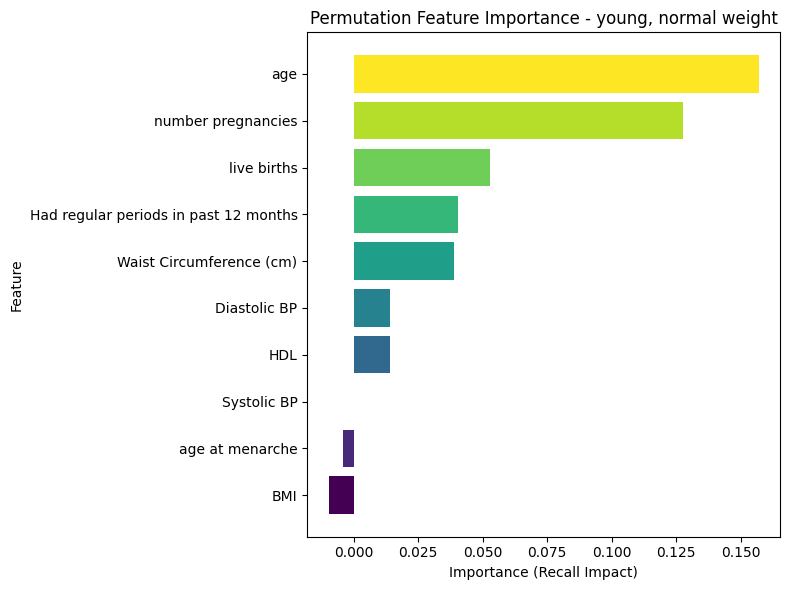

In [ ]:
#Run Permutation Feature Importance
result_young = permutation_importance(
    model_young_lr,
    X_test_scaled_young,
    y_test_young,
    n_repeats=10,
    random_state=42,
    scoring="recall"
)

fi_young = pd.DataFrame({
    "Feature": features,
    "Importance": result_young.importances_mean
}).sort_values(by="Importance", ascending=True)

#Plot Feature Importance Chart
plt.figure(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(fi_young)))

plt.barh(fi_young["Feature"], fi_young["Importance"], color=colors)
plt.xlabel("Importance (Recall Impact)")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - young, normal weight")

plt.tight_layout()
plt.show()

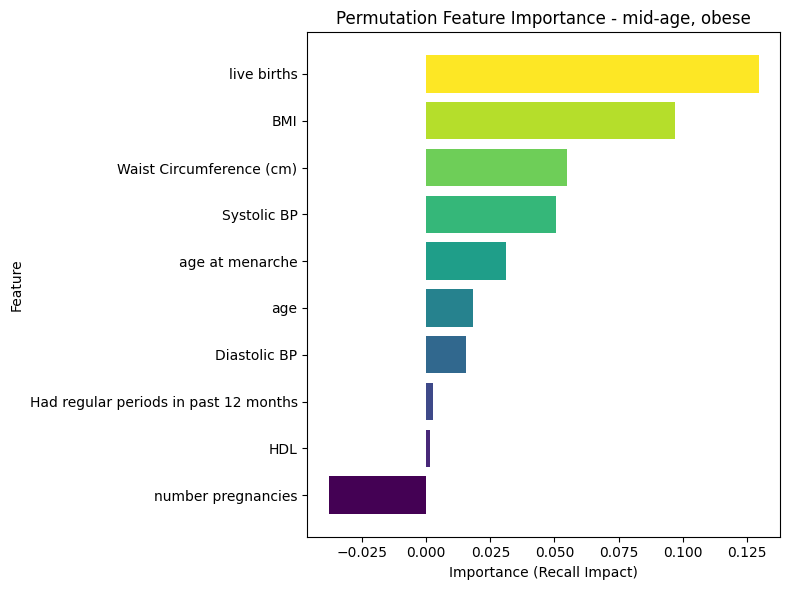

In [ ]:
#Run Permutation Feature Importance
result_mid = permutation_importance(
    model_mid_lr,
    X_test_scaled_mid,
    y_test_mid,
    n_repeats=10,
    random_state=42,
    scoring="recall"
)

fi_mid = pd.DataFrame({
    "Feature": features,
    "Importance": result_mid.importances_mean
}).sort_values(by="Importance", ascending=True)

#Plot Feature Importance Chart
plt.figure(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(fi_mid)))

plt.barh(fi_mid["Feature"], fi_mid["Importance"], color=colors)
plt.xlabel("Importance (Recall Impact)")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance - mid-age, obese")

plt.tight_layout()
plt.show()

/tmp/ipykernel_8159/959209711.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


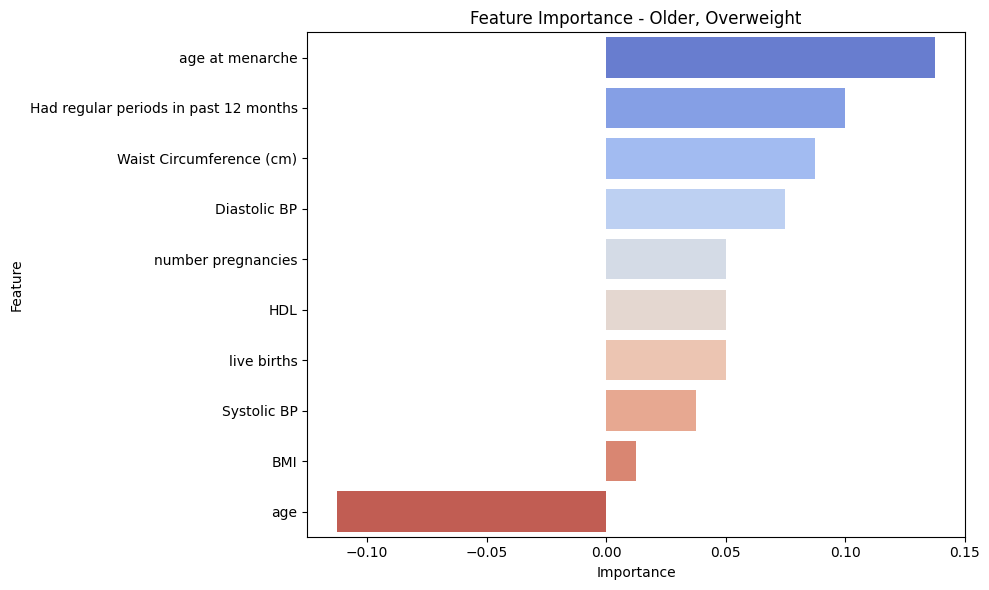

In [ ]:
#Run Permutation Feature Importance
result = permutation_importance(
    model_knn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="recall"
)

feature_importance_knn = pd.DataFrame({
    "Feature": features,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

top_features_knn = feature_importance_knn.head(10)

#Plot Feature Importance Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features_knn,
    x="Importance",
    y="Feature",
    palette="coolwarm"
)

plt.title("Feature Importance - Older, Overweight")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()